In [1]:
import numpy as np
import re
from IPython.lib.deepreload import reload
import pandas as pd
import logomaker as lm
import os, glob, subprocess, math, pickle, time, copy, seqlogo, json
from dna_features_viewer import GraphicFeature, GraphicRecord
from sklearn.metrics import classification_report
import matplotlib.gridspec as gridspec
from Bio import SeqIO, AlignIO, SearchIO
from Bio.Align import MultipleSeqAlignment
from Bio.SeqFeature import SeqFeature, FeatureLocation
from Bio.SeqRecord import SeqRecord
import matplotlib.pyplot as plt
from multiprocessing import Pool
from subprocess import Popen
from dna_features_viewer import BiopythonTranslator
from dna_features_viewer import GraphicFeature, GraphicRecord
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn import preprocessing
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
from multiscorer.multiscorer import MultiScorer
from sklearn.metrics import make_scorer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE, RFECV
from sklearn import svm
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn import tree
from sklearn import neighbors
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso, LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import entropy
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import roc_curve, roc_auc_score, auc, RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer
import seaborn as sns
from matplotlib import rcParams
from sklearnex import patch_sklearn
from sklearn.model_selection import StratifiedShuffleSplit
from Bio.Seq import Seq

In [2]:
with open("2-1.split/GeneMeta.pickle", "rb") as infile:
    GeneMeta = pickle.load(infile)
with open("2-1.split/Gene2Cluster.pickle", "rb") as infile:
    Gene2Cluster = pickle.load(infile)
with open("2-1.split/ClusterMeta.pickle", "rb") as infile:
    ClusterMeta = pickle.load(infile)

In [3]:
with open("revision_sample.txt", "r") as infile:
    test_set_name = {line.strip().split(".")[0] for line in infile}

In [4]:
# =========================
# 1. 입력 파일 경로
# =========================
input_file = "Eco_251216.txt"   # 너 파일명으로 수정

# =========================
# 2. (선택) Assembly barcode -> [SRR, PRJNA] 매핑
#    없으면 빈 dict로 두면 됨
# =========================
meta_map = {
    # "ESC_VC4184AA_AS": ("SRRxxxxx", "PRJNAxxxxx"),
}

# =========================
# 3. 파일 로드
#    - 공백/탭 섞인 파일 대응
# =========================
df = pd.read_csv(
    input_file,
    sep=r"\t",
    engine="python"
)

# 컬럼명 정리 (앞뒤 공백 제거)
df.columns = [c.strip() for c in df.columns]

# =========================
# 4. Serotype 필터링 (O[0-9]+:H[0-9]+)
# =========================
pattern = re.compile(r"^(O\d+):(H\d+)$")
OHtable = {}

for _, row in df.iterrows():
    serotype = str(row["Serotype"]).strip()
    m = pattern.match(serotype)
    if not m:
        continue

    O_type, H_type = m.groups()
    assembly = row["Assembly barcode"].strip()

    # ✅ test_set_name에 없으면 스킵
    if assembly not in test_set_name:
        continue

    # SRR / PRJNA 있으면 사용, 없으면 None
    SRR, PRJNA = meta_map.get(assembly, (None, row["Sample ID"]))

    OHtable[assembly] = [O_type, H_type, SRR, PRJNA]

# =========================
# 5. 결과 확인
# =========================
print(len(OHtable))

meta = pd.read_csv("meta.csv", sep="\t", header=None)
meta.columns = ["acc", "O", "H"]

OHtable.update(meta.set_index("acc").T.to_dict("list"))
print(len(OHtable))

1711
11272


In [5]:
meta = pd.DataFrame(
    [(acc, v[0], v[1]) for acc, v in OHtable.items()],
    columns=["acc", "O", "H"]
)
meta

,acc,O,H
0,ESC_VC4184AA_AS,O146,H21
1,ESC_VC4303AA_AS,O1,H6
2,ESC_VC4473AA_AS,O76,H19
3,ESC_VC4475AA_AS,O111,H8
4,ESC_VC4476AA_AS,O157,H7
...,...,...,...
11267,ESC_ZB9919AA_AS,O23,H15
11268,ESC_ZB9920AA_AS,O76,H19
11269,ESC_ZB9921AA_AS,O84,H2
11270,ESC_ZB9923AA_AS,O126,H27


test samples: 11272
O157    2901
O26     1107
O103     578
O8       322
O111     302
O121     244
O145     202
O25      188
O6       184
O91      175
O149     161
O146     142
O45      133
O55      129
O2       118
O75      112
O9       109
O113     106
O1       105
O165     104
Name: O, dtype: int64


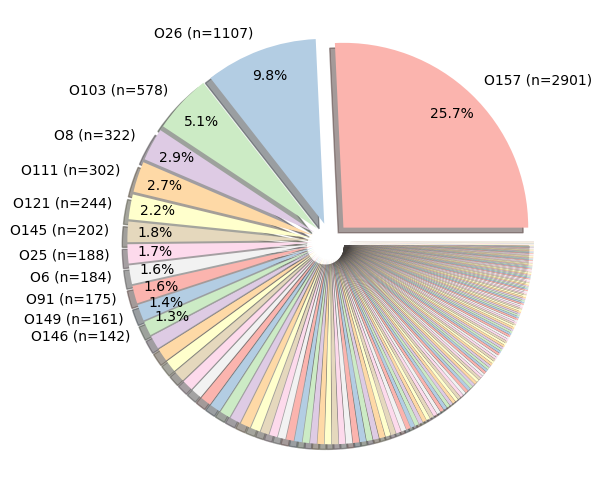

In [37]:
import matplotlib.pyplot as plt

# meta: columns = ["acc", "O", "H"]
# test_set_name: set 또는 list (샘플명들)

# 1) test set에 해당하는 샘플만 추출
#meta_test = meta[meta["acc"].isin(test_set_name)].copy()
meta_test = meta.copy()

# (옵션) 혹시 O가 NaN이면 제거
meta_test = meta_test.dropna(subset=["O"])

print("test samples:", len(meta_test))
print(meta_test["O"].value_counts().head(20))

# 2) pie chart용 설정
def my_autopct(pct):
    return ('%1.1f%%' % pct) if pct >= 1.2 else ''

vc = meta_test["O"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    vc.values,
    labels=[
        f"{name} (n={vc[name]})" if idx < 12 else ""
        for idx, name in enumerate(vc.index)
    ],
    autopct=my_autopct,
    pctdistance=.85,
    explode=[0.1] * len(vc),
    shadow=True,
    colors=plt.cm.Pastel1.colors
)
#plt.title("O-type distribution (test dataset)")
plt.show()


numO	numData	accuracy_mean	accuracy_std	major O	entpy	MBGD_clstrID	CDHIT_clstrID	gene_name	gene_description
*173	8389	0.77	0.01	0.34	0.62	424	1	istB	Transposase; IstB protein ATP-binding protein
*169	8229	0.73	0.01	0.35	0.60	160765	0	yjhS	9-O-acetyl-N-acetylneuraminic acid deacetylase
*189	11229	0.72	0.01	0.26	0.72	2876	0	yfcI	Transposase protein
*188	11030	0.70	0.01	0.26	0.71	2876	1	yfcI	Transposase protein
171	7522	0.80	0.01	0.38	0.59	12018	0	dnaT	Primosomal protein 1
163	7389	0.77	0.01	0.38	0.57	12018	1	dnaT	Primosomal protein 1
*189	11270	0.70	0.00	0.26	0.72	11773	0	yfaL	Membrane autotransporter protein
142	7341	0.78	0.02	0.38	0.56	3067	3	terL	Terminase
131	5530	0.79	0.01	0.40	0.53	269	11	HCS1	DNA helicase protein
*185	10965	0.83	0.01	0.26	0.71	7478	4	wzzE	LPS O-antigen chain length protein
171	7858	0.76	0.01	0.36	0.59	64478	0	ydfR	Qin prophage, uncharacterized protein
161	7484	0.75	0.01	0.38	0.58	2128	0	yjdA	ATP /GTP-binding protein
*189	11266	0.73	0.01	0.26	0.72	346	2	hisC	Histid

*168	8217	0.70	0.01	0.34	0.61	34489	2	D	Head decoration protein
*188	11199	0.79	0.01	0.26	0.71	117	3	glmM	Phosphomannomutase / phosphoglucomutase / phosphoglucosamine mutase
*175	8768	0.72	0.01	0.32	0.65	1687	1	cas3	CRISPR-associated helicase Cas3, protein
172	6561	0.77	0.01	0.36	0.56	5467	6	gpFI	Tail sheath protein
*184	10207	0.70	0.01	0.28	0.69	53477	0	elaD	Deubiquitinase
*175	8216	0.73	0.01	0.35	0.60	20651	0	Q	Antitermination protein
*183	10029	0.72	0.01	0.29	0.68	11805	1	ydiA	Restriction methylase
*189	11272	0.71	0.01	0.26	0.72	310	1	gltD	Glutamate synthase subunit beta oxidoreductase
*188	11195	0.73	0.01	0.26	0.71	1046	0	cpsB	Mannose-1-phosphate guanylyltransferase
139	5329	0.75	0.01	0.33	0.55	136584	0		Putative prophage protein
163	7283	0.77	0.01	0.39	0.56	18036	1	dnaT	DNA-binding protein
171	7521	0.79	0.01	0.38	0.59	18036	0	dnaT	DNA-binding protein
176	6608	0.73	0.01	0.27	0.65	13834	0	recE	Exonuclease VIII protein
168	7928	0.74	0.01	0.35	0.60	3146	16	yaiT	Membrane autotransporte

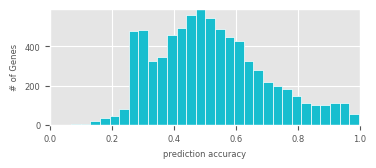

In [39]:
#!/usr/bin/env python3
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# -------------------------------------------------
# (선택) gene metadata가 있으면 여기에 로드해둬야 함
# 예: ClusterMeta = json.load(open("ClusterMeta.json"))
# ClusterMeta[str(clstrMBGD)]["gene"], ["descr"]를 쓸 거면 필수
# -------------------------------------------------
# ClusterMeta = ...

def parse_ok_res_line(line: str):
    """
    OK\tfile=1000_0.vecs\tacc_mean=...\tacc_std=...\tentropy_norm=...
      \tn_classes=...\tn_samples=...\tmost_freq=...\tlabel_mode=O

    Returns dict or None (if not OK)
    """
    line = line.strip()
    if not line.startswith("OK\t"):
        return None

    fields = line.split("\t")
    out = {"status": "OK"}
    for f in fields[1:]:
        if "=" in f:
            k, v = f.split("=", 1)
            out[k] = v
    return out


def parse_cluster_ids_from_filename(file_value: str):
    """
    file=1000_0.vecs  -> (clstrMBGD=1000, clstrCDHIT='0')
    """
    base = os.path.basename(file_value)
    base = base.replace(".vecs", "")
    m = re.match(r"^(\d+)_([^\.]+)$", base)
    if not m:
        return None, None
    return int(m.group(1)), m.group(2)


criterion_count = 0
acc_values = []
genome_values = []
Otype_values = []

target_clstr = set()

print("\t".join([
    "numO", "numData", "accuracy_mean", "accuracy_std",
    "major O", "entpy", "MBGD_clstrID", "CDHIT_clstrID",
    "gene_name", "gene_description"
]))

for af in glob.glob("MBGD_clusters_cdhit_revision_merged/*/*.res"):
    with open(af, "r") as infile:
        for line in infile:
            rec = parse_ok_res_line(line)
            if rec is None:
                continue

            # ---- (예전 log6 변수명으로 맞춰주기) ----
            accuracy_mean = float(rec["acc_mean"])
            accuracy_std  = float(rec["acc_std"])
            norm_entpy    = float(rec["entropy_norm"])
            numO          = int(rec["n_classes"])
            numData       = int(rec["n_samples"])
            numMajor      = float(rec["most_freq"])   # 최빈 클래스 비율

            # 파일명에서 클러스터 ID 복원
            clstrMBGD, clstrCDHIT = parse_cluster_ids_from_filename(rec["file"])

            genome_values.append(numData)
            Otype_values.append(numO)

            if numO >= 10 and numData > 1000:
                acc_values.append(accuracy_mean)

            # ---- 너가 예전에 쓰던 criterion 그대로 ----
            if numO >= 10 and numData >= 5000 and numMajor < 0.4 and accuracy_mean >= 0.7:
                # 별표 조건(더 엄격)
                if numO >= 10 and numData >= 8000 and numMajor < 0.4 and accuracy_mean >= 0.7:
                    star = "*"
                    target_clstr.add((clstrMBGD, clstrCDHIT))
                    criterion_count += 1
                else:
                    star = ""

                # gene meta가 없으면 빈칸 처리
                gene = descr = ""
                try:
                    gene = ClusterMeta[str(clstrMBGD)]["gene"]
                    descr = ClusterMeta[str(clstrMBGD)]["descr"]
                except Exception:
                    pass

                print(
                    f"{star}{numO}\t{numData}\t{accuracy_mean:.2f}\t{accuracy_std:.2f}\t"
                    f"{numMajor:.2f}\t{norm_entpy:.2f}\t{clstrMBGD}\t{clstrCDHIT}\t"
                    f"{gene}\t{descr}"
                )

acc_values = np.array(acc_values, dtype=float)

# ---- histogram (너가 쓰던 스타일 유지) ----
rcParams["figure.figsize"] = (4, 1.5)
plt.style.use("ggplot")
plt.hist(acc_values, bins=30, color="tab:cyan", edgecolor="white")
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.xlim(0, 1)
plt.ylabel("# of Genes", fontsize=6)
plt.xlabel("prediction accuracy", fontsize=6)
plt.margins(0)
plt.savefig("fig2c.png", dpi=300)

print(f"\ncriterion_count={criterion_count}")
print(f"target_clstr size={len(target_clstr)}")


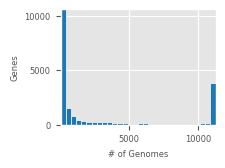

In [40]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

def parse_ok_res_line(line: str):
    line = line.strip()
    if not line.startswith("OK\t"):
        return None

    fields = line.split("\t")
    out = {}
    for f in fields[1:]:
        if "=" in f:
            k, v = f.split("=", 1)
            out[k] = v
    return out

# ---------------------------------------
# 1) genome_values 채우기 (.res 기반)
# ---------------------------------------
genome_values = []

for af in glob.glob("MBGD_clusters_cdhit_revision_merged/*/*.res"):
    with open(af, "r") as infile:
        for line in infile:
            rec = parse_ok_res_line(line)
            if rec is None:
                continue

            # 예전 numData 역할 == n_samples
            numData = int(rec["n_samples"])
            genome_values.append(numData)

# ---------------------------------------
# 2) Histogram 저장 (너 코드 그대로)
# ---------------------------------------
genome_values = np.array(genome_values, dtype="float")

rcParams["figure.figsize"] = (2, 1.5)
plt.style.use("ggplot")
plt.hist(genome_values, bins=30, color="tab:blue", edgecolor="white")
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.ylabel("Genes", fontsize=6)
plt.xlabel("# of Genomes", fontsize=6)
plt.margins(0)
plt.savefig("fig2c.png", dpi=300)


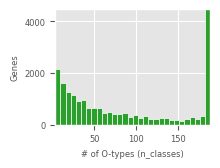

In [41]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

def parse_ok_res_line(line: str):
    line = line.strip()
    if not line.startswith("OK\t"):
        return None

    fields = line.split("\t")
    out = {}
    for f in fields[1:]:
        if "=" in f:
            k, v = f.split("=", 1)
            out[k] = v
    return out

# ---------------------------------------
# 1) Otype_values 채우기 (.res 기반)
# ---------------------------------------
Otype_values = []

for af in glob.glob("MBGD_clusters_cdhit_revision_merged/*/*.res"):
    with open(af, "r") as infile:
        for line in infile:
            rec = parse_ok_res_line(line)
            if rec is None:
                continue

            # 예전 numO 역할 == n_classes
            numO = int(rec["n_classes"])
            Otype_values.append(numO)

# ---------------------------------------
# 2) Histogram 저장 (너 코드 유지)
# ---------------------------------------
Otype_values = np.array(Otype_values, dtype="float")

rcParams["figure.figsize"] = (2, 1.5)
plt.style.use("ggplot")
plt.hist(Otype_values, bins=30, color="tab:green", edgecolor="white")
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.ylabel("Genes", fontsize=6)

# ✅ 여기 원래 코드에 '# of Genomes'라고 되어있는데
#    이 plot은 "O-type 개수(n_classes)" 분포니까 label을 바꾸는 게 정확함
plt.xlabel("# of O-types (n_classes)", fontsize=6)

plt.margins(0)
plt.savefig("fig2c.png", dpi=300)


In [4]:
import pandas as pd

rows = []
for acc, vals in OHtable.items():
    O = vals[0] if len(vals) > 0 else None
    H = vals[1] if len(vals) > 1 else None
    PRJNA = vals[2] if len(vals) > 2 else None
    NCBI_acc = vals[3] if len(vals) > 3 else None

    rows.append({
        "acc": acc,
        "O": O,
        "H": H,
        "NCBI_acc": NCBI_acc,
        "PRJNA": PRJNA
    })

df = pd.DataFrame(rows).sort_values("acc").reset_index(drop=True)

# ✅ index 포함해서 저장 (예전처럼 맨 앞에 빈 헤더 컬럼 생김)
df.to_csv("final_samples.csv", index=True)

print(df.head())
print(f"[DONE] wrote final_samples.csv with index column, rows={len(df)}")


               acc     O    H NCBI_acc PRJNA
0  ESC_AA7966AA_AS  O113  H21     None  None
1  ESC_AA8101AA_AS  O157   H7     None  None
2  ESC_AA8232AA_AS  O157   H7     None  None
3  ESC_AA8336AA_AS  O157   H7     None  None
4  ESC_AA8426AA_AS  O104   H4     None  None
[DONE] wrote final_samples.csv with index column, rows=18203


In [27]:
GMS_annot = {}
for af in fl:
    """
    print(af)
    with open(af, "r") as infile:
        for line in infile:
            print(line)
            seqnum = line.split(" ")[0].lstrip(">")
            print(seqnum)
            break
    """
    
    #blast file name
    with open(af.replace(".faa", ".tab"), "r") as infile:        
        file_name = af.split("/")[-1].replace(".faa", "")
        GMS_annot.setdefault(file_name, {})
        for line in infile:
            seqnum, gene, pident, length = line.strip("\n").split("\t")[0:4]
            _sp, _gene = gene.split(":")
            GMS_annot[file_name][int(seqnum)] = {"species":_sp, "gene":_gene, "pident":pident, "length":length}


In [32]:
import os, glob

count, nometa_count = 0, 0
os.makedirs("MBGD_clusters_faa_revision", exist_ok=True)

fl = glob.glob("Eco_over1Mb_251218/apple/diamond/*.faa")

for idx, af in enumerate(fl):
    if idx % 100 == 0:
        print("Processing:", af)
        print(idx)
    
    file_name = os.path.basename(af).replace(".faa", "")

    if file_name not in OHtable or file_name not in GMS_annot:
        nometa_count += 1
        continue

    O, H = OHtable[file_name][:2]

    with open(af, "r") as infile:
        skipLine = False
        outfiles = []   # 현재 sequence에 대해 열린 파일 핸들들

        for line in infile:
            # ======================
            # FASTA header
            # ======================
            if line.startswith(">"):
                # 이전 sequence 종료 → 파일 닫기
                for fh in outfiles:
                    fh.close()
                outfiles = []

                skipLine = False

                parts = line.strip().split()
                seqnum = int(parts[0].lstrip(">"))
                acc = f"{file_name}|{seqnum}"

                if seqnum not in GMS_annot[file_name]:
                    count += 1
                    skipLine = True
                    continue

                blast_info = GMS_annot[file_name][seqnum]

                if (
                    blast_info["species"] not in Gene2Cluster or
                    blast_info["gene"] not in Gene2Cluster[blast_info["species"]]
                ):
                    count += 1
                    skipLine = True
                    continue

                ClusterList = [
                    int(k)
                    for k in Gene2Cluster[blast_info["species"]][blast_info["gene"]]
                ]

                # header는 여기서 한 번만 출력
                for clstr in ClusterList:
                    subdir = f"MBGD_clusters_faa_revision/{clstr % 1000}"
                    os.makedirs(subdir, exist_ok=True)

                    outpath = f"{subdir}/{clstr}.faa"
                    fh = open(outpath, "a")
                    print(
                        f">{acc}:{O}:{H}:{blast_info['pident']}:{blast_info['length']}",
                        file=fh
                    )
                    outfiles.append(fh)

            # ======================
            # FASTA sequence lines
            # ======================
            else:
                if skipLine:
                    continue

                for fh in outfiles:
                    fh.write(line)

        # 파일 끝났을 때 마지막 sequence 닫기
        for fh in outfiles:
            fh.close()

print("filtered count:", count)
print("no metadata count:", nometa_count)


Processing: Eco_over1Mb_251218/apple/diamond/ESC_BD1373AA_AS.faa
0
Processing: Eco_over1Mb_251218/apple/diamond/ESC_WC2365AA_AS.faa
100
Processing: Eco_over1Mb_251218/apple/diamond/ESC_AD1371AA_AS.faa
200
Processing: Eco_over1Mb_251218/apple/diamond/ESC_CD2119AA_AS.faa
300
Processing: Eco_over1Mb_251218/apple/diamond/ESC_AD4963AA_AS.faa
400
Processing: Eco_over1Mb_251218/apple/diamond/ESC_WC3552AA_AS.faa
500
Processing: Eco_over1Mb_251218/apple/diamond/ESC_BD6283AA_AS.faa
600
Processing: Eco_over1Mb_251218/apple/diamond/ESC_ZC7577AA_AS.faa
700
Processing: Eco_over1Mb_251218/apple/diamond/ESC_YC8561AA_AS.faa
800
Processing: Eco_over1Mb_251218/apple/diamond/ESC_BD1357AA_AS.faa
900
Processing: Eco_over1Mb_251218/apple/diamond/ESC_ZC7321AA_AS.faa
1000
Processing: Eco_over1Mb_251218/apple/diamond/ESC_CD2110AA_AS.faa
1100
Processing: Eco_over1Mb_251218/apple/diamond/ESC_ZC6127AA_AS.faa
1200
Processing: Eco_over1Mb_251218/apple/diamond/ESC_XC3274AA_AS.faa
1300
Processing: Eco_over1Mb_251218/a

In [33]:
#fl = glob.glob("3-1.CD-HIT/clusters_c90/*.c90n5.clstr")
fl = glob.glob("3-1.CD-HIT/clusters_c50_revision/*.c50n2.clstr")
#fl = glob.glob("3-1.CD-HIT/clusters_c50/117.c50n2.clstr")
print(len(fl))

CDHIT_clstr_dict = {}
for af in fl: 
    MBGD_clusterNo = int(af.split("/")[-1].split(".")[0])
    with open(af, "r") as infile:
        for line in infile:
            if line.startswith(">"):
                CDHIT_clusterNo = int(line.split(" ")[-1].strip("\n"))
            else:
                _seqid = line.split(" ")[1].split(":")[0].strip(">")
                CDHIT_clstr_dict.setdefault(_seqid, [])
                CDHIT_clstr_dict[_seqid].append((MBGD_clusterNo, CDHIT_clusterNo))

15528


In [34]:
print(len(CDHIT_clstr_dict))

57889560


In [35]:
CDHIT_clstr_dict["ESC_GC3128AA_AS.result|3531"]

[(159993, 2), (64478, 2)]

In [41]:
def worker(proc_id):
    count = 0
    nometa_count = 0
    skipLine = True
    header_idx = -1

    with open(INPUT, "r") as infile:
        for line in infile:
            if line.startswith(">"):
                header_idx += 1

                # 이 proc가 맡을 header가 아니면 skip
                if header_idx % NPROC != proc_id:
                    skipLine = True
                    continue

                skipLine = False
                acc = line.strip().lstrip(">")
                sample_name = acc.split("|")[0].split(".")[0].strip("_genomic")

                if acc not in CDHIT_clstr_dict:
                    count += 1
                    skipLine = True
                    continue

                if sample_name not in OHtable:
                    nometa_count += 1
                    skipLine = True
                    continue

                O, H = OHtable[sample_name][:2]
                cdhit_info_list = CDHIT_clstr_dict[acc]

            else:
                if skipLine:
                    continue

                for cdhit_info in cdhit_info_list:
                    bucket = cdhit_info[0] % 1000
                    outdir = f"{OUTDIR}/{bucket}"
                    os.makedirs(outdir, exist_ok=True)

                    outfile = (
                        f"{outdir}/"
                        f"{cdhit_info[0]}_{cdhit_info[1]}.vecs.proc{proc_id}"
                    )

                    with open(outfile, "a") as out:
                        print(f">{acc}:{O}:{H}", file=out)
                        print(line, end="", file=out)

    return count, nometa_count

In [42]:
from multiprocessing import Pool

NPROC = 40
INPUT = "5-1.ESM/GMS2.faa.txt"
OUTDIR = "MBGD_clusters_cdhit_revision"

os.makedirs(OUTDIR, exist_ok=True)

with Pool(NPROC) as p:
    results = p.map(worker, range(NPROC))

total_count = sum(r[0] for r in results)
total_nometa = sum(r[1] for r in results)

print("Excluded (CDHIT):", total_count)
print("Excluded (No meta):", total_nometa)

Excluded (CDHIT): 334488
Excluded (No meta): 0


In [44]:
import os
import glob
from multiprocessing import Pool

# =========================
# CONFIG
# =========================
NPROC = 40
IN_GLOB = "/home/disk6/230504_enterobase_data/Eco_over1Mb_251218/apple/Embedded/*.txt"
OUTROOT = "MBGD_clusters_cdhit_revision_2"

os.makedirs(OUTROOT, exist_ok=True)

FILES = sorted(glob.glob(IN_GLOB))
if not FILES:
    raise RuntimeError(f"No files matched: {IN_GLOB}")

# -------------------------
# 주의: 아래 두 dict는 기존 코드처럼 미리 만들어져 있어야 함
# - CDHIT_clstr_dict: key=acc ("ESC_XXXX|223"), value=list of tuples e.g. [(cluster_id, rep_id), ...]
# - OHtable: key=sample_name ("ESC_XXXX"), value=tuple/list where [:2] = (O, H)
# -------------------------


def process_one_file(path: str, proc_id: int):
    """
    Embedded 파일 1개 처리.
    header: >223 ...
    acc: {filename_wo_ext}|{223}
    """
    count_no_cdhit = 0
    count_no_meta = 0

    sample_name = os.path.basename(path).rsplit(".", 1)[0]  # ESC_ZC9964AA_AS

    skipLine = True
    cdhit_info_list = None
    O = H = None
    acc = None

    with open(path, "r") as f:
        for line in f:
            if line.startswith(">"):
                skipLine = False

                parts = line[1:].strip().split()
                if not parts:
                    skipLine = True
                    continue

                idx_token = parts[0]  # "223"
                acc = f"{sample_name}|{idx_token}"

                if acc not in CDHIT_clstr_dict:
                    count_no_cdhit += 1
                    skipLine = True
                    continue

                if sample_name not in OHtable:
                    count_no_meta += 1
                    skipLine = True
                    continue

                O, H = OHtable[sample_name][:2]
                cdhit_info_list = CDHIT_clstr_dict[acc]

            else:
                if skipLine:
                    continue

                # vector line (1 line)
                for cdhit_info in cdhit_info_list:
                    cluster_id = cdhit_info[0]
                    rep_id = cdhit_info[1]

                    bucket = cluster_id % 1000
                    outdir = f"{OUTROOT}/{bucket}"
                    os.makedirs(outdir, exist_ok=True)

                    # 동시 write 충돌 방지용 proc suffix
                    outpath = f"{outdir}/{cluster_id}_{rep_id}.vecs.proc{proc_id}"

                    with open(outpath, "a") as out:
                        out.write(f">{acc}:{O}:{H}\n")
                        out.write(line)  # line already contains '\n'

    return count_no_cdhit, count_no_meta


def worker(proc_id: int):
    """
    파일 단위로 분산:
    FILES[i]를 i % NPROC == proc_id 인 것만 처리
    """
    total_no_cdhit = 0
    total_no_meta = 0

    for i, path in enumerate(FILES):
        if (i % NPROC) != proc_id:
            continue
        a, b = process_one_file(path, proc_id)
        total_no_cdhit += a
        total_no_meta += b

    return total_no_cdhit, total_no_meta


if __name__ == "__main__":
    with Pool(NPROC) as p:
        results = p.map(worker, range(NPROC))

    total_no_cdhit = sum(x[0] for x in results)
    total_no_meta = sum(x[1] for x in results)

    print("Excluded (CDHIT missing):", total_no_cdhit)
    print("Excluded (OH meta missing):", total_no_meta)


Excluded (CDHIT missing): 66645
Excluded (OH meta missing): 0


In [10]:
import glob
import os

criterion_count = 0
acc_values = []
genome_values = []
Otype_values = []

target_clstr = set()

print("\t".join([
    "numO", "numData", "accuracy_mean", "accuracy_std",
    "major O", "entpy",
    "MBGD_clstrID", "CDHIT_clstrID",
    "gene_name", "gene_description"
]))

for af in glob.glob("MBGD_clusters_cdhit_revision_merged/*/*.res"):
    with open(af, "r") as infile:
        for line in infile:
            line = line.strip()
            if not line:
                continue

            # Only accept OK lines
            # Example:
            # OK\tfile=1000_0.vecs\tacc_mean=0.8123\tacc_std=0.0211\tentropy_norm=0.55\tn_classes=12\tn_samples=9000\tmost_freq=0.33\tlabel_mode=O
            parts = line.split("\t")
            status = parts[0]
            if status != "OK":
                continue

            kv = {}
            for p in parts[1:]:
                if "=" in p:
                    k, v = p.split("=", 1)
                    kv[k] = v

            # ---- extract cluster id from file name ----
            # file can be "1000_0.vecs" or sometimes might not exist -> fallback to path base
            fname = kv.get("file", os.path.basename(af))          # e.g. "1000_0.vecs" or "1000_0.res"
            clstr = os.path.splitext(fname)[0]                    # -> "1000_0"
            clstrMBGD = int(clstr.split("_")[0])
            clstrCDHIT = clstr.split("_", 1)[1]

            # ---- numeric fields ----
            accuracy_mean = float(kv["acc_mean"])
            accuracy_std  = float(kv["acc_std"])
            norm_entpy    = float(kv["entropy_norm"])
            numO          = int(kv["n_classes"])
            numData       = int(kv["n_samples"])
            numMajor      = float(kv["most_freq"])

            genome_values.append(numData)
            Otype_values.append(numO)

            if numO >= 10 and numData > 1000:
                acc_values.append(accuracy_mean)

            # ---- same criteria as your original ----
            if numO >= 10 and numData >= 5000 and numMajor < 0.4 and accuracy_mean >= 0.75:
                gene = ClusterMeta[str(clstrMBGD)]["gene"]
                descr = ClusterMeta[str(clstrMBGD)]["descr"]

                if numO >= 10 and numData >= 8000 and numMajor < 0.4 and accuracy_mean >= 0.75:
                    print(
                        "*{}\t{}\t{:.2f}\t{:.2f}\t{:.2f}\t{:.2f}\t{}\t{}\t{}\t{}".format(
                            numO, numData, accuracy_mean, accuracy_std,
                            numMajor, norm_entpy,
                            clstrMBGD, clstrCDHIT,
                            gene, descr
                        )
                    )
                    target_clstr.add((clstrMBGD, clstrCDHIT))
                    criterion_count += 1
                else:
                    print(
                        "{}\t{}\t{:.2f}\t{:.2f}\t{:.2f}\t{:.2f}\t{}\t{}\t{}\t{}".format(
                            numO, numData, accuracy_mean, accuracy_std,
                            numMajor, norm_entpy,
                            clstrMBGD, clstrCDHIT,
                            gene, descr
                        )
                    )

# 필요하면 마지막에 criterion_count 출력
# print("criterion_count:", criterion_count)


numO	numData	accuracy_mean	accuracy_std	major O	entpy	MBGD_clstrID	CDHIT_clstrID	gene_name	gene_description
*173	8389	0.77	0.01	0.34	0.62	424	1	istB	Transposase; IstB protein ATP-binding protein
171	7522	0.80	0.01	0.38	0.59	12018	0	dnaT	Primosomal protein 1
163	7389	0.77	0.01	0.38	0.57	12018	1	dnaT	Primosomal protein 1
142	7341	0.78	0.02	0.38	0.56	3067	3	terL	Terminase
131	5530	0.79	0.01	0.40	0.53	269	11	HCS1	DNA helicase protein
*185	10965	0.83	0.01	0.26	0.71	7478	4	wzzE	LPS O-antigen chain length protein
171	7858	0.76	0.01	0.36	0.59	64478	0	ydfR	Qin prophage, uncharacterized protein
166	7681	0.78	0.01	0.37	0.59	5226	1	H	Phage tail tape measure protein
*188	10709	0.78	0.01	0.27	0.71	1911	0	wzxC	Polysaccharide biosynthesis protein
*175	8173	0.80	0.01	0.35	0.63	3102	0	rhsD	Type IV secretion protein Rhs
*188	10710	0.84	0.01	0.27	0.71	19	11	wcaL	Glycosyl transferase family 1
*177	9167	0.76	0.01	0.31	0.65	45732	0	ydaW	DNA-binding protein
*189	11271	0.75	0.01	0.26	0.72	5330	0	wzc	Tyrosine p

In [6]:
target_clstr = [(19, '11'), (66, '0'), (117, '3'), (201, "1"), (684, "0"), (1911, "0"), (2726, "0"), (7478, "4"), (35854, "1")]

In [67]:
import os
import numpy as np
from collections import Counter, defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


def parse_vec_header(header_line: str):
    h = header_line.strip().lstrip(">")
    parts = h.split(":")
    acc_raw = parts[0]
    sample_acc = acc_raw.split("|")[0].split(".")[0].replace("_genomic", "")

    O_label = parts[1] if len(parts) >= 2 and parts[1] else None
    H_label = parts[2] if len(parts) >= 3 and parts[2] else None
    return sample_acc, O_label, H_label


def read_vecs_meanpooled(vecs_path: str, label_mode: str = "O", expected_dim: int = 320):
    """
    Reads alternating lines:
      >header
      v1 v2 ... vD
    Mean-pools vectors per sample_acc.
    """
    sum_vec = {}
    cnt_vec = defaultdict(int)
    label_of = {}

    cur_sample, cur_label = None, None

    with open(vecs_path, "r") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue

            if line.startswith(">"):
                sample_acc, O_label, H_label = parse_vec_header(line)

                if label_mode == "O":
                    if O_label is None:
                        cur_sample, cur_label = None, None
                        continue
                    lab = O_label
                elif label_mode == "OH":
                    if (O_label is None) or (H_label is None):
                        cur_sample, cur_label = None, None
                        continue
                    lab = f"{O_label}:{H_label}"
                else:
                    raise ValueError("label_mode must be 'O' or 'OH'")

                cur_sample, cur_label = sample_acc, lab
                continue

            if cur_sample is None:
                continue

            vec = np.fromstring(line, sep=" ", dtype=float)
            if vec.size == 0:
                continue
            if expected_dim is not None and vec.size != expected_dim:
                raise ValueError(f"Dim mismatch in {vecs_path}: got {vec.size}, expected {expected_dim} (sample={cur_sample})")

            if cur_sample not in sum_vec:
                sum_vec[cur_sample] = vec.copy()
                cnt_vec[cur_sample] = 1
                label_of[cur_sample] = cur_label
            else:
                if label_of[cur_sample] != cur_label:
                    raise ValueError(f"Label conflict for {cur_sample} in {vecs_path}: {label_of[cur_sample]} vs {cur_label}")
                sum_vec[cur_sample] += vec
                cnt_vec[cur_sample] += 1

    accs = sorted(sum_vec.keys())
    if not accs:
        return None, None, []

    X = np.vstack([sum_vec[a] / cnt_vec[a] for a in accs])
    y = np.array([label_of[a] for a in accs], dtype=object)
    return X, y, accs


# -------------------------
# main (target_clstr, test_set_name은 이미 정의되어 있다고 가정)
# -------------------------
label_mode = "O"        # 필요하면 "OH"로
expected_dim = 320
n_repeat = 10

rf_base_params = dict(
    n_estimators=100,
    criterion="entropy",
    max_depth=50,
    n_jobs=40,
    class_weight="balanced",
)

print("\t".join([
    "clstr_id", "ver", "vecs_file",
    "n_all", "n_train", "n_test",
    "rf_test_acc_mean", "rf_test_acc_std"
]))

for clstr_id, ver in target_clstr:
    vecs_path = os.path.join(
        "MBGD_clusters_cdhit_revision_merged",
        str(clstr_id % 1000),
        f"{clstr_id}_{ver}.vecs"
    )
    base = os.path.basename(vecs_path)

    if not os.path.exists(vecs_path):
        print(f"{clstr_id}\t{ver}\t{base}\tMISSING")
        continue

    try:
        X, y, accs = read_vecs_meanpooled(vecs_path, label_mode=label_mode, expected_dim=expected_dim)
        if X is None or len(y) == 0:
            print(f"{clstr_id}\t{ver}\t{base}\tSKIP(no_valid_samples)")
            continue

        is_test = np.array([a in test_set_name for a in accs], dtype=bool)

        X_train, y_train = X[~is_test], y[~is_test]
        X_test,  y_test  = X[is_test],  y[is_test]

        n_all = len(y)
        n_train = len(y_train)
        n_test = len(y_test)

        if n_test == 0:
            print(f"{clstr_id}\t{ver}\t{base}\t{n_all}\t{n_train}\t{n_test}\tSKIP(no_test)\t-")
            continue
        if n_train == 0 or len(set(y_train.tolist())) < 2:
            print(f"{clstr_id}\t{ver}\t{base}\t{n_all}\t{n_train}\t{n_test}\tSKIP(train_too_small)\t-")
            continue

        acc_list = []
        for rep in range(n_repeat):
            clf = RandomForestClassifier(
                **rf_base_params,
                random_state=33 + rep
            )
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            acc_list.append(accuracy_score(y_test, y_pred))

        acc_mean = float(np.mean(acc_list))
        acc_std = float(np.std(acc_list, ddof=1)) if len(acc_list) > 1 else 0.0

        print(
            f"{clstr_id}\t{ver}\t{base}\t"
            f"{n_all}\t{n_train}\t{n_test}\t"
            f"{acc_mean:.6f}\t{acc_std:.6f}"
        )

    except Exception as e:
        print(f"{clstr_id}\t{ver}\t{base}\tERROR\t{repr(e)}")


clstr_id	ver	vecs_file	n_all	n_train	n_test	rf_test_acc_mean	rf_test_acc_std
19	11	19_11.vecs	10710	9119	1591	0.774419	0.012059
66	0	66_0.vecs	11260	9550	1710	0.703216	0.009495
117	3	117_3.vecs	11199	9503	1696	0.740448	0.050132
201	1	201_1.vecs	11251	9543	1708	0.751581	0.003864
684	0	684_0.vecs	11266	9556	1710	0.738889	0.003930
1911	0	1911_0.vecs	10709	9118	1591	0.683407	0.007478
2726	0	2726_0.vecs	10710	9119	1591	0.782778	0.001831
7478	4	7478_4.vecs	10965	9296	1669	0.779569	0.009031
35854	1	35854_1.vecs	10786	9193	1593	0.834149	0.051686


In [59]:
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
from collections import defaultdict


def parse_vec_header(header_line: str):
    h = header_line.strip().lstrip(">")
    parts = h.split(":")
    acc_raw = parts[0]
    sample_acc = acc_raw.split("|")[0].split(".")[0].replace("_genomic", "")

    O_label = parts[1] if len(parts) >= 2 and parts[1] else None
    H_label = parts[2] if len(parts) >= 3 and parts[2] else None
    return sample_acc, O_label, H_label


def read_vecs_meanpooled(vecs_path: str, label_mode: str = "O", expected_dim: int = 320):
    """
    Reads alternating lines:
      >header
      v1 v2 ... vD
    Mean-pools vectors per sample_acc.
    """
    sum_vec = {}
    cnt_vec = defaultdict(int)
    label_of = {}

    cur_sample, cur_label = None, None

    with open(vecs_path, "r") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue

            if line.startswith(">"):
                sample_acc, O_label, H_label = parse_vec_header(line)

                if label_mode == "O":
                    if O_label is None:
                        cur_sample, cur_label = None, None
                        continue
                    lab = O_label
                elif label_mode == "OH":
                    if (O_label is None) or (H_label is None):
                        cur_sample, cur_label = None, None
                        continue
                    lab = f"{O_label}:{H_label}"
                else:
                    raise ValueError("label_mode must be 'O' or 'OH'")

                cur_sample, cur_label = sample_acc, lab
                continue

            if cur_sample is None:
                continue

            vec = np.fromstring(line, sep=" ", dtype=float)
            if vec.size == 0:
                continue
            if expected_dim is not None and vec.size != expected_dim:
                raise ValueError(
                    f"Dim mismatch in {vecs_path}: got {vec.size}, expected {expected_dim} (sample={cur_sample})"
                )

            if cur_sample not in sum_vec:
                sum_vec[cur_sample] = vec.copy()
                cnt_vec[cur_sample] = 1
                label_of[cur_sample] = cur_label
            else:
                if label_of[cur_sample] != cur_label:
                    raise ValueError(
                        f"Label conflict for {cur_sample} in {vecs_path}: {label_of[cur_sample]} vs {cur_label}"
                    )
                sum_vec[cur_sample] += vec
                cnt_vec[cur_sample] += 1

    accs = sorted(sum_vec.keys())
    if not accs:
        return None, None, []

    X = np.vstack([sum_vec[a] / cnt_vec[a] for a in accs])
    y = np.array([label_of[a] for a in accs], dtype=object)
    return X, y, accs


def make_global_split_stratify_by_meta_O(meta, train_ratio=0.7, seed=2026,
                                         assign_singletons_to="train"):
    """
    meta의 O로 전역 7:3 stratified split (1회).
    - O 클래스 샘플이 1개뿐인(singleton) 것은 Stratified split에서 제외
    - 제외된 singleton acc는 기본적으로 train(또는 test)로 강제 할당 가능
    반환:
      global_test_set_name(set), global_train_set_name(set), dropped_singletons(list)
    """
    m = meta[["acc", "O"]].copy()
    m["acc"] = m["acc"].astype(str)
    m["O"] = m["O"].astype(str)
    m = m.dropna(subset=["acc", "O"])

    # 클래스별 샘플 수 계산
    vc = m["O"].value_counts()
    ok_classes = set(vc[vc >= 2].index)
    singleton_classes = set(vc[vc == 1].index)

    m_ok = m[m["O"].isin(ok_classes)].copy()
    m_single = m[m["O"].isin(singleton_classes)].copy()

    dropped_singletons = m_single["acc"].tolist()

    acc_all = m_ok["acc"].values
    y = m_ok["O"].values

    if len(np.unique(y)) < 2:
        raise ValueError("After removing singleton classes, need >=2 classes to stratify.")

    sss = StratifiedShuffleSplit(
        n_splits=1,
        train_size=train_ratio,
        random_state=seed
    )
    idx = np.arange(len(acc_all))
    train_idx, test_idx = next(sss.split(idx, y))

    global_train = set(acc_all[train_idx].tolist())
    global_test  = set(acc_all[test_idx].tolist())

    # singleton acc를 어디에 넣을지 결정 (기본 train 추천)
    if assign_singletons_to == "train":
        global_train.update(dropped_singletons)
    elif assign_singletons_to == "test":
        global_test.update(dropped_singletons)
    elif assign_singletons_to == "drop":
        pass
    else:
        raise ValueError("assign_singletons_to must be 'train', 'test', or 'drop'")

    return global_test, global_train, dropped_singletons


# -------------------------
# main (target_clstr, meta는 이미 정의돼 있다고 가정)
# -------------------------
label_mode = "O"       # 필요하면 "OH"
expected_dim = 320
n_repeat = 10
split_seed = 2026      # 전역 split 재현성
train_ratio = 0.7

rf_base_params = dict(
    n_estimators=100,
    criterion="entropy",
    max_depth=50,
    n_jobs=40,
    #class_weight="balanced",
)

# 1) 전역 split 생성 (meta 기준 1회)
global_test_set_name, global_train_set_name, singleton_accs = make_global_split_stratify_by_meta_O(
    meta, train_ratio=0.7, seed=split_seed, assign_singletons_to="train"
)

print("Singleton O classes samples (forced to train):", len(singleton_accs))
# 필요하면 파일로 기록
with open("singleton_accs.txt", "w") as w:
    w.write("\n".join(sorted(singleton_accs)) + "\n")
# (선택) 전역 split 기록
with open("global_test_set_name.txt", "w") as w:
    w.write("\n".join(sorted(global_test_set_name)) + "\n")
with open("global_train_set_name.txt", "w") as w:
    w.write("\n".join(sorted(global_train_set_name)) + "\n")

print("\t".join([
    "clstr_id", "ver", "vecs_file",
    "n_all_vecs", "n_train_vecs", "n_test_vecs",
    "rf_test_acc_mean", "rf_test_acc_std"
]))

for clstr_id, ver in target_clstr:
    vecs_path = os.path.join(
        "MBGD_clusters_cdhit_revision_merged",
        str(clstr_id % 1000),
        f"{clstr_id}_{ver}.vecs"
    )
    base = os.path.basename(vecs_path)

    if not os.path.exists(vecs_path):
        print(f"{clstr_id}\t{ver}\t{base}\tMISSING")
        continue

    try:
        X, y, accs = read_vecs_meanpooled(vecs_path, label_mode=label_mode, expected_dim=expected_dim)
        if X is None or len(y) == 0:
            print(f"{clstr_id}\t{ver}\t{base}\tSKIP(no_valid_samples)")
            continue

        # 2) vecs에 있는 샘플들 중에서 전역 split을 적용
        is_test = np.array([a in global_test_set_name for a in accs], dtype=bool)
        is_train = np.array([a in global_train_set_name for a in accs], dtype=bool)

        # 전역 split에 없는 샘플(메타에 없거나 라벨 누락 등)은 제외하는 게 안전
        keep = is_test | is_train
        X2 = X[keep]
        y2 = y[keep]
        accs2 = [a for a, k in zip(accs, keep) if k]

        is_test2 = np.array([a in global_test_set_name for a in accs2], dtype=bool)

        X_train, y_train = X2[~is_test2], y2[~is_test2]
        X_test,  y_test  = X2[is_test2],  y2[is_test2]

        n_all = len(y2)
        n_train = len(y_train)
        n_test = len(y_test)

        if n_test == 0:
            print(f"{clstr_id}\t{ver}\t{base}\t{n_all}\t{n_train}\t{n_test}\tSKIP(no_test)\t-")
            continue
        if n_train == 0 or len(set(y_train.tolist())) < 2:
            print(f"{clstr_id}\t{ver}\t{base}\t{n_all}\t{n_train}\t{n_test}\tSKIP(train_too_small)\t-")
            continue

        acc_list = []
        for rep in range(n_repeat):
            clf = RandomForestClassifier(
                **rf_base_params,
                random_state=33 + rep
            )
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            acc_list.append(accuracy_score(y_test, y_pred))

        acc_mean = float(np.mean(acc_list))
        acc_std = float(np.std(acc_list, ddof=1)) if len(acc_list) > 1 else 0.0

        print(
            f"{clstr_id}\t{ver}\t{base}\t"
            f"{n_all}\t{n_train}\t{n_test}\t"
            f"{acc_mean:.6f}\t{acc_std:.6f}"
        )

    except Exception as e:
        print(f"{clstr_id}\t{ver}\t{base}\tERROR\t{repr(e)}")

Singleton O classes samples (forced to train): 12
clstr_id	ver	vecs_file	n_all_vecs	n_train_vecs	n_test_vecs	rf_test_acc_mean	rf_test_acc_std
19	11	19_11.vecs	10710	7496	3214	0.839764	0.001414
66	0	66_0.vecs	11260	7885	3375	0.774015	0.000948
117	3	117_3.vecs	11199	7844	3355	0.795976	0.000913
201	1	201_1.vecs	11251	7878	3373	0.782923	0.001354
684	0	684_0.vecs	11266	7889	3377	0.806130	0.001670
1911	0	1911_0.vecs	10709	7495	3214	0.783012	0.001416
2726	0	2726_0.vecs	10710	7496	3214	0.829714	0.001736
7478	4	7478_4.vecs	10965	7676	3289	0.836181	0.001522
35854	1	35854_1.vecs	10786	7551	3235	0.884699	0.001030


In [44]:
#target_file = "684_0" #684_0, 117_3, 66_0
target_file = "684"

am = AlignIO.read("MSA/{}.addfrag.mafft.msa".format(target_file), "fasta")

###

first_seq = am[0]
positions_to_remove = [pos for pos, char in enumerate(first_seq) if char == '-']
new_alignment = MultipleSeqAlignment([])
for record in am:
    new_seq = "".join([char for pos, char in enumerate(record.seq) if pos not in positions_to_remove])
    new_record = SeqRecord(Seq(new_seq), id=record.id, description=record.description)
    new_alignment.append(new_record)
    
am = new_alignment

###

alignment_length = am.get_alignment_length()
aa_composition = []

for i in range(alignment_length):
    column = am[:, i]
    aa_counts = {}
    total_count = len(column)

    for aa in column:
        if aa not in aa_counts:
            aa_counts[aa] = 1
        else:
            aa_counts[aa] += 1

    # Calculate the frequency of each amino acid
    aa_frequencies = {aa: count / total_count for aa, count in aa_counts.items()}
    aa_composition.append(aa_frequencies)
    
###

max_composition = [max(position.values()) for position in aa_composition]
df_max_composition = pd.DataFrame({
    'Position': range(1, len(max_composition) + 1),
    'Max Composition': max_composition
})

[TopN O-types] ['O157', 'O26', 'O103', 'O8', 'O111']
[Groups used in chi-square] ['O157', 'O26', 'O103', 'O8', 'O111', 'Other']


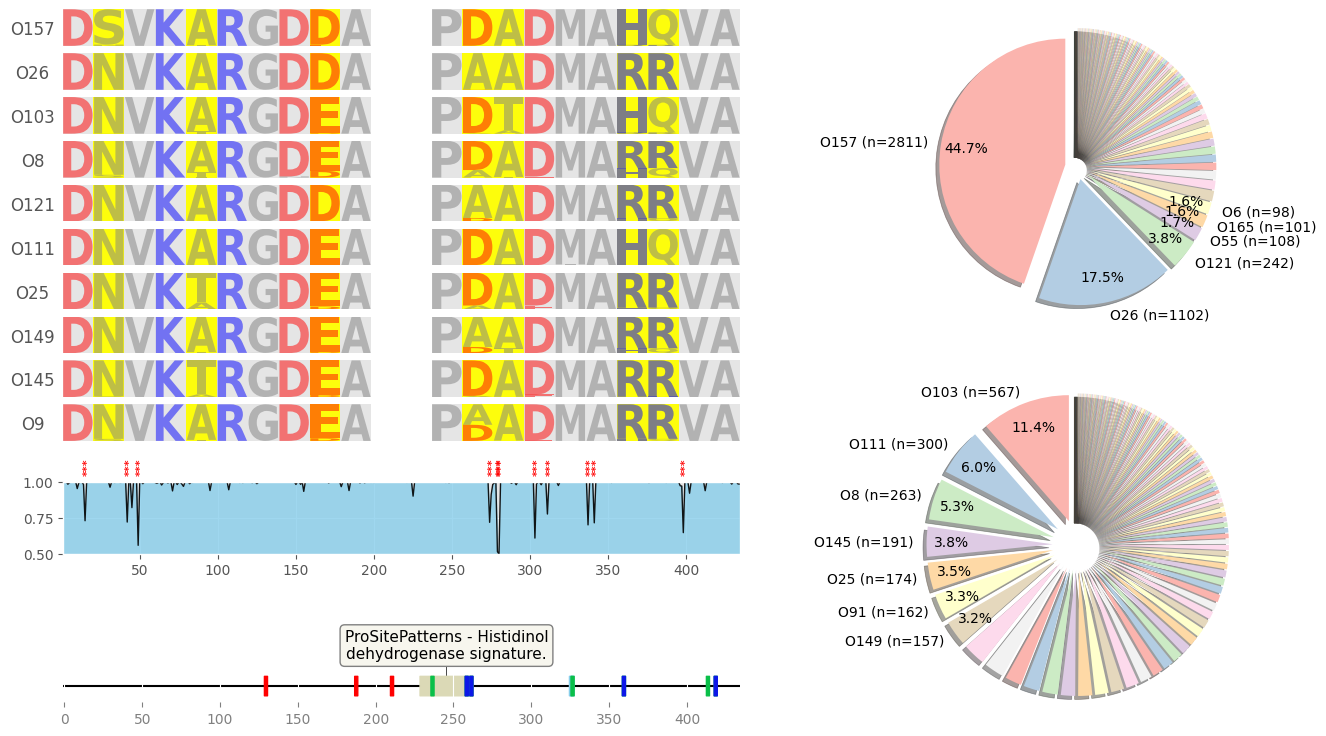

In [54]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import logomaker as lm

from collections import Counter, defaultdict
from scipy.stats import chi2_contingency


########################################
# 설정
########################################
#target_file = "684_0"
target_file = "684.revision"
plt.figure(figsize=(16, 9))

target_pos = 48
OtypeList = ["O157", "O26", "O103", "O8", "O121", "O111", "O25", "O149", "O145", "O9"]

CONS_THRESH = 0.8
INCLUDE_GAP = False
MIN_TOTAL = 20

POS_IS_1BASED = True      # df_max_composition["Position"]이 1-based면 True, 0-based면 False

TOP_K = 5  # Top N O-type + Other

# Bonferroni
ALPHA = 0.05

# 별 표시 스타일 (axes 좌표 기준)
STAR_ROT = 90
STAR_FONTSIZE = 8
#STAR_FONTSIZE = 5
STAR_ALPHA = 0.95
STAR_X_OFFSET = 5
#STAR_X_OFFSET = 4
STAR_AXES_Y = 1.01        # axes y
STAR_AXES_Y_OFFSET = 0.2  # ✅ axes y에서 +0.2 오프셋
#STAR_AXES_Y_OFFSET = 0.1  # ✅ axes y에서 +0.2 오프셋
STAR_COLOR = "red"


########################################
# 유틸 함수
########################################
def p_to_stars(p_adj):
    if p_adj < 0.001:
        return "***"
    elif p_adj < 0.01:
        return "**"
    elif p_adj < 0.05:
        return "*"
    else:
        return ""


def get_topk_otypes(am, top_k=5):
    c = Counter()
    for record in am:
        ot = record.id.split(":")[1]
        c[ot] += 1
    top = [ot for ot, _ in c.most_common(top_k)]
    return top, c


def compute_chi_square_pvals_topk_other(
    am,
    positions,
    top_otypes,
    include_gap=False,
    min_total=20,
    pos_is_1based=True
):
    top_set = set(top_otypes)

    # TopK + Other 그룹으로 서열 묶기
    seqs_by_group = defaultdict(list)
    for record in am:
        ot = record.id.split(":")[1]
        grp = ot if ot in top_set else "Other"
        seqs_by_group[grp].append(str(record.seq))

    group_order = top_otypes + ["Other"]
    group_order = [g for g in group_order if len(seqs_by_group.get(g, [])) > 0]

    out = []
    for pos in positions:
        seq_idx = pos - 1 if pos_is_1based else pos

        aa_set = set()
        total_n = 0
        col_counts = {}

        for g in group_order:
            cnt = Counter()
            for s in seqs_by_group[g]:
                if seq_idx < 0 or seq_idx >= len(s):
                    continue
                aa = s[seq_idx]
                if (aa == "-") and (not include_gap):
                    continue
                cnt[aa] += 1
                aa_set.add(aa)
                total_n += 1
            col_counts[g] = cnt

        if total_n < min_total or len(aa_set) < 2 or len(group_order) < 2:
            out.append((pos, np.nan, np.nan, total_n, 0, 0))
            continue

        aas = sorted(aa_set)
        table = np.zeros((len(group_order), len(aas)), dtype=int)
        for i, g in enumerate(group_order):
            for j, aa in enumerate(aas):
                table[i, j] = col_counts[g].get(aa, 0)

        keep_rows = table.sum(axis=1) > 0
        keep_cols = table.sum(axis=0) > 0
        table2 = table[keep_rows][:, keep_cols]

        if table2.shape[0] < 2 or table2.shape[1] < 2:
            out.append((pos, np.nan, np.nan, total_n, table2.shape[0], table2.shape[1]))
            continue

        chi2, pval, dof, expected = chi2_contingency(table2, correction=False)
        out.append((pos, pval, chi2, int(table2.sum()), table2.shape[0], table2.shape[1]))

    df = pd.DataFrame(out, columns=["Position", "pval", "chi2", "N", "n_groups", "n_aas"])
    return df, group_order


########################################
# (1) conservation < threshold 인 position들만 테스트 대상으로 선택
########################################
df_max_composition["Position"] = df_max_composition["Position"].astype(int)
df_max_composition["Max Composition"] = df_max_composition["Max Composition"].astype(float)

positions_to_test = df_max_composition.loc[
    df_max_composition["Max Composition"] < CONS_THRESH,
    "Position"
].tolist()

# Top5 선정
top5, otype_counts = get_topk_otypes(am, top_k=TOP_K)
print("[TopN O-types]", top5)

# (2) Chi-square (Top5 + Other)
stat_df, group_order = compute_chi_square_pvals_topk_other(
    am=am,
    positions=positions_to_test,
    top_otypes=top5,
    include_gap=INCLUDE_GAP,
    min_total=MIN_TOTAL,
    pos_is_1based=POS_IS_1BASED
)
print("[Groups used in chi-square]", group_order)

# (3) Bonferroni correction
mask = stat_df["pval"].notna() & np.isfinite(stat_df["pval"])
m = int(mask.sum())

stat_df["p_bonf"] = np.nan
if m > 0:
    stat_df.loc[mask, "p_bonf"] = np.minimum(stat_df.loc[mask, "pval"] * m, 1.0)

sig_col = "p_bonf"
stat_df["stars"] = stat_df[sig_col].apply(
    lambda v: "" if (v is None or not np.isfinite(v)) else p_to_stars(v)
)

sig_df = stat_df.loc[stat_df["stars"] != ""].copy()
sig_df = sig_df.sort_values("Position")


########################################
# ====== 여기부터 네 원래 코드 흐름 ======
########################################
msa_group_by = {}
target_pos_ratio = {}

for record in am:
    Otype = record.id.split(":")[1]
    msa_group_by.setdefault(Otype, [])
    msa_group_by[Otype].append((str(record.seq[40:50]), str(record.seq[272:282])))

    target_pos_ratio.setdefault(record.seq[target_pos], {})
    target_pos_ratio[record.seq[target_pos]].setdefault(Otype, 0)
    target_pos_ratio[record.seq[target_pos]][Otype] += 1

target_res = sorted(target_pos_ratio.items(), key=lambda item: sum(item[1].values()), reverse=True)

outermost_grid = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1], wspace=0.2)

# 오른쪽 pie 2개
right_grid = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[1, 1], subplot_spec=outermost_grid[1])

rx1 = plt.subplot(right_grid[0])
first_res = target_res[0]
O_stats = sorted(first_res[1].items(), key=lambda item: item[1], reverse=True)

def my_autopct_1(pct):
    return ('%1.1f%%' % pct) if pct >= 1.5 else ''

rx1.pie(
    [stats[1] for stats in O_stats],
    labels=[lb + " (n={})".format(O_stats[idx][1]) if idx < 6 else "" for idx, lb in enumerate(stats[0] for stats in O_stats)],
    shadow=True,
    pctdistance=0.80,
    colors=plt.cm.Pastel1.colors,
    autopct=my_autopct_1,
    explode=[0.1] * len(O_stats),
    startangle=90,
)

rx2 = plt.subplot(right_grid[1])
second_res = target_res[1]
O_stats = sorted(second_res[1].items(), key=lambda item: item[1], reverse=True)

def my_autopct_2(pct):
    return ('%1.1f%%' % pct) if pct >= 3.0 else ''

rx2.pie(
    [stats[1] for stats in O_stats],
    labels=[lb + " (n={})".format(O_stats[idx][1]) if idx < 7 else "" for idx, lb in enumerate(stats[0] for stats in O_stats)],
    shadow=True,
    pctdistance=0.8,
    colors=plt.cm.Pastel1.colors,
    autopct=my_autopct_2,
    explode=[0.2] * len(O_stats),
    startangle=90,
)

# 왼쪽 패널
outer_grid = gridspec.GridSpecFromSubplotSpec(3, 1, height_ratios=[6, 1, 1.5], subplot_spec=outermost_grid[0])
inner_grid = gridspec.GridSpecFromSubplotSpec(
    nrows=len(OtypeList),
    ncols=2,
    subplot_spec=outer_grid[0],
    width_ratios=[1, 1]
)

highlights = [
    [1, 4, 8],
    [1, 2, 6, 7],
]

for idx, Otype in enumerate(OtypeList):
    for i in range(2):
        ax = plt.subplot(inner_grid[idx, i])
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        if i == 0:
            ax.set_ylabel(OtypeList[idx], rotation="horizontal")
            ax.yaxis.set_label_coords(-0.1, 0.2)

        target_alignment = [seqs[i] for seqs in msa_group_by.get(Otype, [])]
        counts_mat = lm.alignment_to_matrix(target_alignment)
        aa_logo = lm.Logo(counts_mat, color_scheme="charge", ax=ax, alpha=0.5)
        for position in highlights[i]:
            aa_logo.highlight_position(p=position, color="Yellow", alpha=0.95)

#############################
# InterProScan 결과
#############################
features = []

with open(f"MSA/{target_file}.interproscan.tsv", "r") as infile:
    for line in infile:
        fields = line.strip().split("\t")
        feat_name = fields[3] + " - " + fields[5]
        if fields[3] not in ["ProSitePatterns"]:
            continue
        _start, _end = int(fields[6]), int(fields[7])

        features.append(
            GraphicFeature(
                start=_start, end=_end, strand=0,
                label=feat_name,
                open_left=True, open_right=True,
                color="#dbd9b6", linecolor="#dbd9b6",
            )
        )

with open("MSA/684.uniprot.features.json", "r") as infile:
    uniprot_features = json.load(infile)

for uniprot_feature in uniprot_features["features"]:
    _start = uniprot_feature["location"]["start"]["value"]
    _end = uniprot_feature["location"]["end"]["value"]
    flag = False

    if "ligand" in uniprot_feature:
        _name = None
        if uniprot_feature["ligand"]["name"] == "NAD(+)":
            _color, _linecolor, _alpha = "red", "red", 1
        elif uniprot_feature["ligand"]["name"] == "Zn(2+)":
            _color, _linecolor, _alpha = "#0c17e8", "#0c17e8", 0.4
        elif uniprot_feature["ligand"]["name"] == "substrate":
            _color, _linecolor, _alpha = "#0abf49", "#0abf49", 1
        else:
            _color, _linecolor, _alpha = "gray", "gray", 0.6
        flag = True

    elif uniprot_feature.get("type", "") == "Active site":
        _name = None
        _color, _linecolor, _alpha = "skyblue", "skyblue", 1
        flag = True

    if flag:
        features.append(
            GraphicFeature(
                start=_start, end=_end, strand=0,
                label=_name,
                open_left=True, open_right=True,
                color=_color, linecolor=_linecolor, alpha=_alpha,
            )
        )

ax2 = plt.subplot(outer_grid[2])
record = GraphicRecord(sequence_length=int(max(df_max_composition["Position"])), features=features, feature_level_height=0)
record.plot(ax=ax2, max_label_length=100, max_line_length=40)

# conservation plot
ax3 = plt.subplot(outer_grid[1])
ax3.plot(df_max_composition["Position"], df_max_composition["Max Composition"], marker='', color="black", alpha=0.9, linewidth=1)
ax3.fill_between(df_max_composition["Position"], df_max_composition["Max Composition"], color='skyblue', alpha=0.8)
ax3.margins(x=0)
ax3.set_ylim(0.5, 1)

########################################
# (추가) 별 찍기: axes 좌표 기준 (x+8, y=STAR_AXES_Y+0.2)
########################################
x_min, x_max = ax3.get_xlim()

for _, row in sig_df.iterrows():
    pos = int(row["Position"])
    stars = row["stars"]
    if stars == "":
        continue

    x_star = pos + STAR_X_OFFSET

    if x_star < x_min or x_star > x_max:
        continue

    ax3.text(
        x_star,
        STAR_AXES_Y + STAR_AXES_Y_OFFSET,
        stars,
        transform=ax3.get_xaxis_transform(),  # x는 데이터좌표 / y는 axes좌표
        ha="center",
        va="bottom",
        color=STAR_COLOR,
        fontsize=STAR_FONTSIZE,
        fontweight="bold",
        rotation=STAR_ROT,
        rotation_mode="anchor",
        alpha=STAR_ALPHA,
        clip_on=False
    )

plt.show()


In [7]:
DataMat_list = []
dimVec = 320

for clstrMBGD, clstrCDHIT in target_clstr:
    temp_vecs = {}
    DataMat = {"acc":[], "answer":[]}
    for i in range(dimVec):
        DataMat["MBGD{}_CDHIT{}_v{}".format(clstrMBGD, clstrCDHIT, i)] = []        
        
    with open("MBGD_clusters_cdhit_revision_merged/{}/{}_{}.vecs".format(int(clstrMBGD)%1000, clstrMBGD, clstrCDHIT), "r") as infile:
        for line in infile:
            if line.startswith(">"): # odd lines
                acc, O, H = line.strip("\n").strip(">").split(":")[:3]
                continue
            else:
                sample_acc = acc.split("|")[0].split(".")[0].replace("_genomic", "")
                if sample_acc in OHtable:
                    vecs = line.strip("\n").split(" ")
                    temp_vecs.setdefault(sample_acc, [])
                    temp_vecs[sample_acc].append([float(vec) for vec in vecs])
                    
        duplicate_count = 0
        for sample_acc in temp_vecs:
            mean_vec = np.mean(temp_vecs[sample_acc], axis = 0)
            DataMat["acc"].append(sample_acc)
            DataMat["answer"].append(OHtable[sample_acc][0])
            for i in range(len(mean_vec)):
                DataMat["MBGD{}_CDHIT{}_v{}".format(clstrMBGD, clstrCDHIT, i)].append(mean_vec[i])
            if len(temp_vecs[sample_acc]) > 1: duplicate_count += 1
        #print(duplicate_count)
        
    DataMat_list.append(pd.DataFrame(DataMat))

In [63]:
import numpy as np
import pandas as pd

from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# =========================
# 설정
# =========================
nRepeat = 10
base_seed = 33
n_jobs = 40

rf_kwargs = dict(
    n_estimators=100,
    n_jobs=n_jobs,
    criterion="entropy",
    max_depth=10,
    class_weight=None,   # ✅ balanced 사용 안 함
)

ZERO_DIV = 0  # classification_report에서 0 division 처리

def mean_std(vals):
    vals = np.asarray(vals, dtype=float)
    if len(vals) < 2:
        return float(vals.mean()), 0.0
    return float(vals.mean()), float(vals.std(ddof=1))

# 결과 row들 (gene x O-type)
rows = []

# (선택) gene 단위 overall acc도 같이 저장하고 싶으면
gene_overall_rows = []

# =========================
# loop: gene별(DataMat별)
# =========================
for idx, df in enumerate(DataMat_list):
    clstrMBGD, clstrCDHIT = target_clstr[idx]

    # ---- 고정 global split ----
    train_df = df[df["acc"].isin(global_train_set_name)].copy()
    test_df  = df[df["acc"].isin(global_test_set_name)].copy()

    if len(train_df) == 0 or len(test_df) == 0:
        continue

    # ---- test에만 있고 train에 없는 클래스는 제거(학습 불가) ----
    train_classes = set(train_df["answer"].unique())
    test_df = test_df[test_df["answer"].isin(train_classes)].copy()
    if len(test_df) == 0:
        continue

    # ---- X/y ----
    drop_cols = ["acc", "answer"]
    if "entero_acc" in train_df.columns:
        drop_cols.append("entero_acc")

    X_train = train_df.drop(columns=drop_cols).fillna(0)
    y_train = train_df["answer"]

    X_test  = test_df.drop(columns=drop_cols).fillna(0)
    y_test  = test_df["answer"]

    # feature mismatch 방어
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    # ---- 이번 gene에서 "test에 실제로 존재하는 O-type"만 성능 저장 ----
    otypes_in_test = sorted(y_test.unique())

    # otype별 metric 누적 버퍼
    # buff[O]["precision"] = [..10개..] 이런 구조
    buff = {O: defaultdict(list) for O in otypes_in_test}

    # overall acc도 10회 저장 (선택)
    acc_list = []

    # =========================
    # 10회 반복 학습/평가
    # =========================
    for r in range(nRepeat):
        seed = base_seed + r
        clf = RandomForestClassifier(random_state=seed, **rf_kwargs)
        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)
        acc_list.append(accuracy_score(y_test, y_pred))

        rep = classification_report(
            y_test, y_pred,
            output_dict=True,
            zero_division=ZERO_DIV
        )

        # 각 O-type별 precision/recall/f1/support 누적
        for O in otypes_in_test:
            # classification_report dict 키는 라벨 문자열 그대로 들어감
            if O not in rep:
                # 예측/라벨 상황에 따라 드물게 누락될 수 있어 방어
                continue
            buff[O]["precision"].append(rep[O]["precision"])
            buff[O]["recall"].append(rep[O]["recall"])
            buff[O]["f1-score"].append(rep[O]["f1-score"])
            buff[O]["support"].append(rep[O]["support"])  # 반복마다 동일할 것

    # =========================
    # gene별 overall acc mean/std (선택)
    # =========================
    acc_m, acc_s = mean_std(acc_list)
    gene_overall_rows.append({
        "idx": idx,
        "MBGD_ID": clstrMBGD,
        "CDHIT_ID": clstrCDHIT,
        "train_n": len(train_df),
        "test_n": len(test_df),
        "overall_acc_mean": acc_m,
        "overall_acc_std": acc_s,
    })

    # =========================
    # O-type별 mean/std row 생성
    # =========================
    for O in otypes_in_test:
        # support는 반복마다 같으므로 첫 값 사용
        support_val = int(buff[O]["support"][0]) if len(buff[O]["support"]) else 0

        p_m, p_s = mean_std(buff[O]["precision"]) if len(buff[O]["precision"]) else (np.nan, np.nan)
        r_m, r_s = mean_std(buff[O]["recall"])    if len(buff[O]["recall"]) else (np.nan, np.nan)
        f_m, f_s = mean_std(buff[O]["f1-score"])  if len(buff[O]["f1-score"]) else (np.nan, np.nan)

        rows.append({
            "idx": idx,
            "MBGD_ID": clstrMBGD,
            "CDHIT_ID": clstrCDHIT,
            "Otype": O,
            "test_support": support_val,
            "precision_mean": p_m,
            "precision_std": p_s,
            "recall_mean": r_m,
            "recall_std": r_s,
            "f1_mean": f_m,
            "f1_std": f_s,
        })

# =========================
# 저장
# =========================
perO_df = pd.DataFrame(rows)
perO_out = "revision_RF_fixedsplit_repeat10_perOtype_metrics.tsv"
perO_df.to_csv(perO_out, sep="\t", index=False)
print("Saved:", perO_out)

overall_df = pd.DataFrame(gene_overall_rows)
overall_out = "revision_RF_fixedsplit_repeat10_overallAcc.tsv"
overall_df.to_csv(overall_out, sep="\t", index=False)
print("Saved:", overall_out)

perO_df.head(10)


Saved: revision_RF_fixedsplit_repeat10_perOtype_metrics.tsv
Saved: revision_RF_fixedsplit_repeat10_overallAcc.tsv


,idx,MBGD_ID,CDHIT_ID,Otype,test_support,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,0,19,11,O1,32,0.511503,1.468372e-02,0.718750,0.000000,0.597561,1.015376e-02
1,0,19,11,O10,5,1.000000,0.000000e+00,0.400000,0.000000,0.571429,1.170278e-16
2,0,19,11,O100,5,0.625000,0.000000e+00,1.000000,0.000000,0.769231,0.000000e+00
3,0,19,11,O101,3,0.025000,7.905694e-02,0.033333,0.105409,0.028571,9.035079e-02
4,0,19,11,O102,7,1.000000,0.000000e+00,0.857143,0.000000,0.923077,0.000000e+00
5,0,19,11,O103,172,0.976943,6.907556e-03,0.958721,0.001839,0.967733,3.277713e-03
6,0,19,11,O104,30,0.903226,1.170278e-16,0.933333,0.000000,0.918033,1.170278e-16
7,0,19,11,O105,2,1.000000,0.000000e+00,0.500000,0.000000,0.666667,1.170278e-16
8,0,19,11,O106,1,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
9,0,19,11,O107,1,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000e+00


In [67]:
# meta["O"]가 전체 O-type 메타라고 가정
major_O_list = (
    meta["O"]
    .value_counts()
    .drop(index="O111", errors="ignore")  # O111 제거
    .head(10)                             # top 10
    .index
    .tolist()
)

major_O_list

['O157', 'O26', 'O103', 'O8', 'O121', 'O145', 'O25', 'O6', 'O91', 'O149']

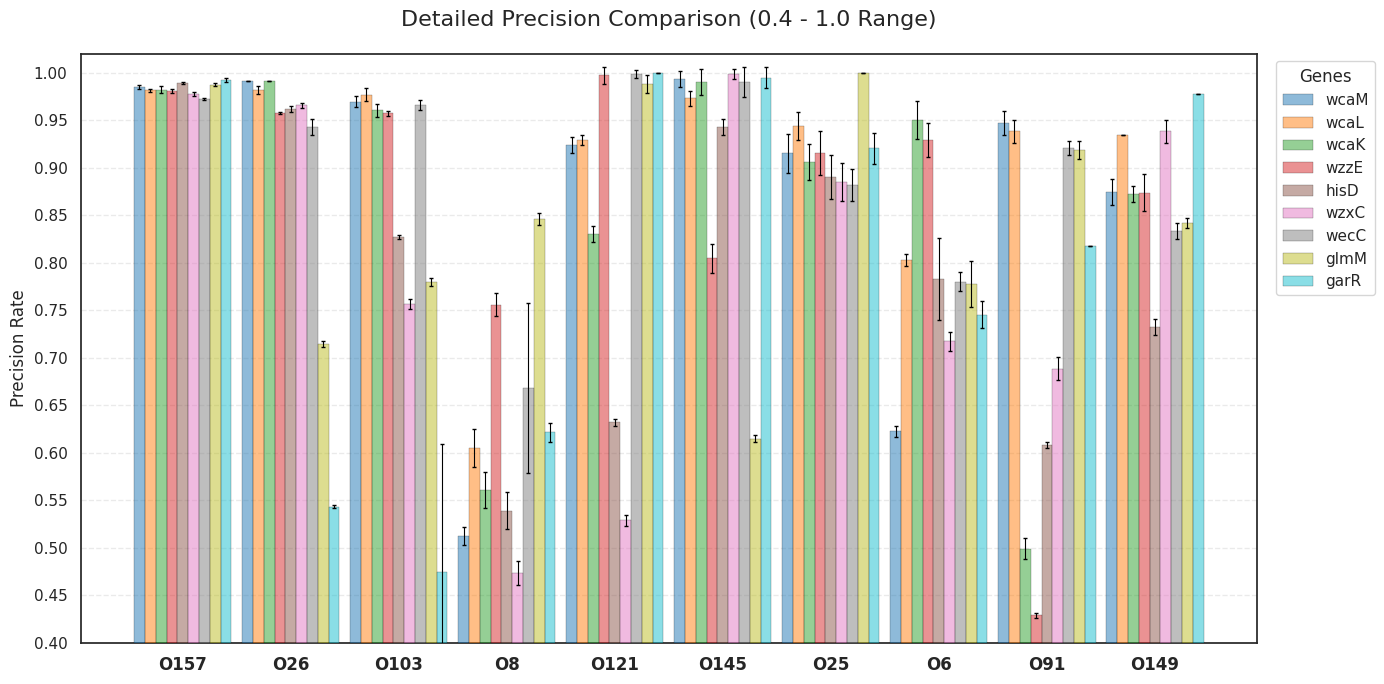

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 설정
# -------------------------
metric_mean = "precision_mean"   # Otype별 "accuracy"로 쓰려면 recall_mean이 가장 자연스러움
metric_std  = "precision_std"
metric_label = "Accuracy"

# figure size
fig_w, fig_h = 14, 7

# gene name 매핑 (MBGD_ID -> gene symbol)
geneName = {
    35854:"wcaM",
    19:"wcaL",
    2726:"wcaK",
    7478:"wzzE",
    684:"hisD",
    1911:"wzxC",
    201:"wecC",
    117:"glmM",
    66:"garR"
}

# -------------------------
# 1) major O list (Top10, O111 제외) - 이미 만들어뒀으면 이 블록은 생략 가능
# -------------------------
major_O_list = (
    meta["O"].value_counts()
    .drop(index="O111", errors="ignore")
    .head(10)
    .index
    .tolist()
)

# -------------------------
# 2) major O만 필터 + Gene 라벨 만들기
# -------------------------
df_plot = perO_df[perO_df["Otype"].isin(major_O_list)].copy()

# Gene 키는 MBGD_ID만으로 충분(legend에 gene symbol 쓸 거라)
df_plot["Gene"] = df_plot["MBGD_ID"].astype(int)

# 이번 plot에 포함할 gene 후보는 geneName에 있는 것만 (원하면 이 줄 삭제 가능)
df_plot = df_plot[df_plot["Gene"].isin(geneName.keys())].copy()

# legend 라벨(표시명): gene symbol (필요하면 MBGD id도 같이 표시)
df_plot["GeneLabel"] = df_plot["Gene"].map(geneName)
# df_plot["GeneLabel"] = df_plot["Gene"].map(lambda x: f"{geneName.get(x,'NA')} (MBGD{x})")

# Otype 순서 고정
df_plot["Otype"] = pd.Categorical(df_plot["Otype"], categories=major_O_list, ordered=True)

# -------------------------
# 3) mean/std 매트릭스 만들기 (otypes x genes)
# -------------------------
otypes = major_O_list
genes = sorted(df_plot["Gene"].unique().tolist(), key=lambda x: list(geneName.keys()).index(x) if x in geneName else 10**9)
labels = [geneName.get(g, f"MBGD{g}") for g in genes]

mean_mat = np.full((len(otypes), len(genes)), np.nan, dtype=float)
std_mat  = np.full((len(otypes), len(genes)), np.nan, dtype=float)

row_map = df_plot.set_index(["Otype", "Gene"])
for i, O in enumerate(otypes):
    for j, G in enumerate(genes):
        if (O, G) in row_map.index:
            mean_mat[i, j] = float(row_map.loc[(O, G), metric_mean])
            std_mat[i, j]  = float(row_map.loc[(O, G), metric_std])

# NaN은 0으로 패딩(그 gene가 그 Otype에 없어서 계산 안된 경우)
mean_mat = np.nan_to_num(mean_mat, nan=0.0)
std_mat  = np.nan_to_num(std_mat,  nan=0.0)

# -------------------------
# 4) matplotlib grouped bar + std errorbar
# -------------------------
x = np.arange(len(otypes))
nG = len(genes)
bar_w = 0.8 / max(nG, 1)

plt.figure(figsize=(fig_w, fig_h))

# 1. 막대 너비를 더 확보하여 꽉 차 보기에 변경
bar_w = 0.9 / nG 

for j, (G, lab) in enumerate(zip(genes, labels)):
    offset = (j - (nG - 1) / 2) * bar_w
    xpos = x + offset

    # 막대 그래프
    plt.bar(xpos, mean_mat[:, j], width=bar_w, color=colors[j], 
            edgecolor='black', linewidth=0.3, label=lab, alpha=0.5, zorder=3)
    
    # 에러바 (더 얇고 깔끔하게)
    plt.errorbar(xpos, mean_mat[:, j], yerr=std_mat[:, j], 
                 fmt='none', ecolor='black', elinewidth=0.8, capsize=1.5, zorder=4)

# 2. 가시성의 핵심: Y축 범위를 데이터 집중 구간으로 제한
# 최솟값이 0 근처인 것도 있으므로, 0.4~1.0 정도로 잡거나 
# 하단 여백을 줄이기 위해 설정을 변경합니다.
plt.ylim(0.4, 1.02)  # 0.4 이하의 데이터는 바닥에 붙어서 차이를 보여줌

# 3. 보조 그리드 추가 (수치 읽기 용이)
plt.gca().set_yticks(np.arange(0.4, 1.01, 0.05)) # 0.05 단위로 눈금
plt.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

# 제목 및 라벨
plt.title("Detailed Precision Comparison (0.4 - 1.0 Range)", fontsize=16, pad=20)
plt.ylabel("Precision Rate", fontsize=12)

# X축 레이블 가독성 (O형 이름이 중요하므로 더 크게)
plt.xticks(x, otypes, rotation=0, fontsize=12, fontweight='bold') 

# 범례를 그래프 밖으로 빼고 배경색을 넣어서 깔끔하게
plt.legend(title="Genes", bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

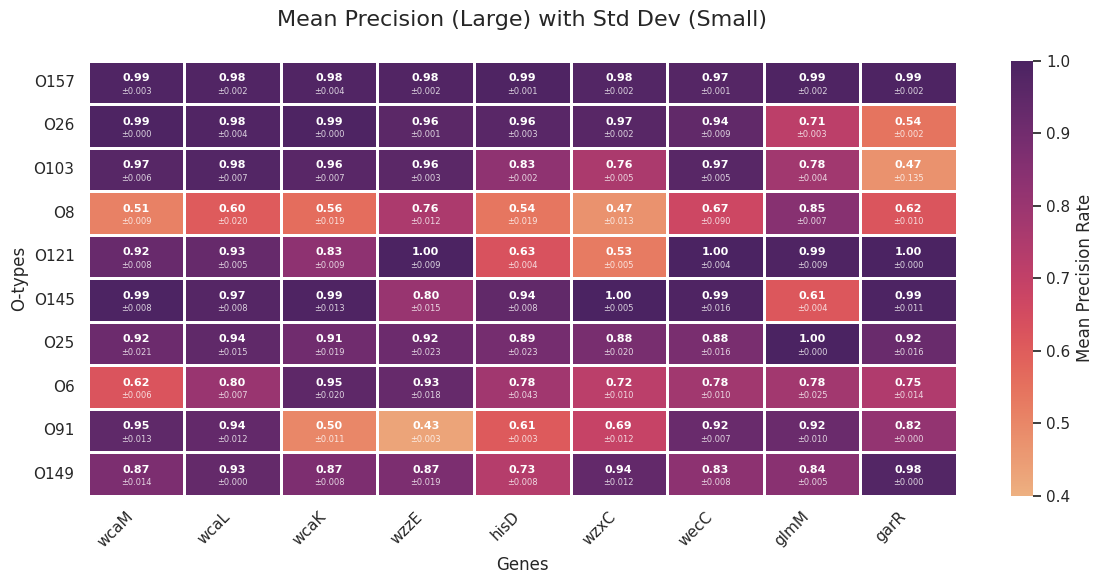

In [115]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

# 1. 히트맵 그리기 (annot=False로 설정하여 숫자를 비웁니다)
ax = sns.heatmap(
    mean_mat, 
    annot=False,  # 직접 그릴 것이므로 끕니다
    cmap="flare", 
    vmin=0.4, vmax=1.0, 
    xticklabels=labels, 
    yticklabels=otypes, 
    linewidths=1,
    cbar_kws={'label': 'Mean Precision Rate'}
)

# 2. 각 셀을 순회하며 텍스트 직접 삽입
for i in range(len(otypes)):
    for j in range(len(labels)):
        m = mean_mat[i, j]
        s = std_mat[i, j]
        
        # 평균값 (위쪽 위치, 기본 크기)
        ax.text(j + 0.5, i + 0.4, f"{m:.2f}", 
                ha='center', va='center', 
                fontsize=8, weight='bold', color='white')
        
        # 표준편차 (아래쪽 위치, 작은 크기)
        ax.text(j + 0.5, i + 0.7, f"±{s:.3f}", 
                ha='center', va='center', 
                fontsize=6, weight='normal', color='white', alpha=0.8)

# 3. 레이아웃 마무리
plt.title("Mean Precision (Large) with Std Dev (Small)", fontsize=16, pad=25)
plt.xlabel("Genes", fontsize=12)
plt.ylabel("O-types", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [10]:
DataMat_allgene = DataMat_list[1]

for i in [j for j in range(2, len(DataMat_list))]:
    DataMat_allgene = DataMat_allgene.merge(DataMat_list[i].drop('answer', axis=1), left_on = "acc", right_on = "acc", how="left")

# ✅ NaN → 0 padding
feat_cols = [c for c in DataMat_allgene.columns if c not in ["acc", "answer"]]
#DataMat_allgene[feat_cols] = DataMat_allgene[feat_cols].fillna(0)
DataMat_allgene[feat_cols] = DataMat_allgene[feat_cols].fillna(0)
    
DataMat_allgene

,acc,answer,MBGD66_CDHIT0_v0,MBGD66_CDHIT0_v1,MBGD66_CDHIT0_v2,MBGD66_CDHIT0_v3,MBGD66_CDHIT0_v4,MBGD66_CDHIT0_v5,MBGD66_CDHIT0_v6,MBGD66_CDHIT0_v7,...,MBGD35854_CDHIT1_v310,MBGD35854_CDHIT1_v311,MBGD35854_CDHIT1_v312,MBGD35854_CDHIT1_v313,MBGD35854_CDHIT1_v314,MBGD35854_CDHIT1_v315,MBGD35854_CDHIT1_v316,MBGD35854_CDHIT1_v317,MBGD35854_CDHIT1_v318,MBGD35854_CDHIT1_v319
0,ESC_IC7812AA_AS,O88,-0.029049,-0.111378,0.060906,0.084345,0.239207,0.113037,0.100078,-0.059398,...,-0.123887,-0.060899,0.058487,0.044181,-0.109555,-0.188628,-0.294002,0.210873,0.077293,-0.146775
1,ESC_FC7499AA_AS,O165,0.017471,-0.098253,0.044164,0.094046,0.289313,0.117564,0.126162,-0.058540,...,-0.112613,-0.065061,0.052983,0.045323,-0.112348,-0.207183,-0.284386,0.207727,0.065295,-0.147312
2,ESC_FC7503AA_AS,O165,0.017471,-0.098253,0.044164,0.094046,0.289313,0.117564,0.126162,-0.058540,...,-0.112613,-0.065061,0.052983,0.045323,-0.112348,-0.207183,-0.284386,0.207727,0.065295,-0.147312
3,ESC_FC7549AA_AS,O165,0.017471,-0.098253,0.044164,0.094046,0.289313,0.117564,0.126162,-0.058540,...,-0.112613,-0.065061,0.052983,0.045323,-0.112348,-0.207183,-0.284386,0.207727,0.065295,-0.147312
4,ESC_FC7535AA_AS,O165,0.037773,-0.067536,0.077534,0.104504,0.261324,0.121542,0.100193,-0.058970,...,-0.112613,-0.065061,0.052983,0.045323,-0.112348,-0.207183,-0.284386,0.207727,0.065295,-0.147312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11255,ESC_ZC6620AA_AS,O157,0.024930,-0.071718,0.047972,0.078488,0.251649,0.169840,0.105669,-0.051514,...,-0.121357,-0.052911,0.050306,0.040330,-0.097224,-0.203720,-0.287342,0.200765,0.065390,-0.144366
11256,ESC_ZC7196AA_AS,O182,0.023200,-0.071853,0.046742,0.076756,0.250738,0.170173,0.106058,-0.051912,...,-0.123121,-0.060152,0.059283,0.042419,-0.126093,-0.194607,-0.299139,0.205537,0.063116,-0.146786
11257,ESC_ZC7711AA_AS,O131,0.020396,-0.068434,0.042162,0.074134,0.247387,0.169289,0.101723,-0.055423,...,-0.113292,-0.056309,0.049461,0.046091,-0.115007,-0.195050,-0.288074,0.201088,0.068167,-0.139102
11258,ESC_ZC8781AA_AS,O121,0.037257,-0.076154,0.049903,0.074258,0.247862,0.172966,0.104864,-0.057565,...,-0.125614,-0.040933,0.046582,0.050726,-0.118676,-0.197320,-0.301532,0.200188,0.060957,-0.137601


In [9]:
with open("global_test_set_name.txt", "r") as infile:
    global_test_set_name = {line.strip("\n") for line in infile}
with open("global_train_set_name.txt", "r") as infile:
    global_train_set_name = {line.strip("\n") for line in infile}

In [19]:
patch_sklearn()
rcParams['figure.figsize'] = 8,8

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


train: (7885, 2562) test: (3375, 2562)


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

              precision    recall  f1-score   support

          O1     0.9091    0.9375    0.9231        32
         O10     0.7500    0.6000    0.6667         5
        O100     0.6250    1.0000    0.7692         5
        O101     0.5000    0.4286    0.4615         7
        O102     1.0000    0.8571    0.9231         7
        O103     0.9941    0.9769    0.9854       173
        O104     0.9655    0.9032    0.9333        31
        O105     0.3333    0.5000    0.4000         2
        O106     0.0000    0.0000    0.0000         1
        O107     1.0000    1.0000    1.0000         1
        O108     0.9375    1.0000    0.9677        15
        O109     0.6250    0.5556    0.5882         9
         O11     1.0000    0.8333    0.9091        12
        O110     0.5000    1.0000    0.6667         2
        O111     0.9783    0.9890    0.9836        91
        O112     0.5714    0.8000    0.6667         5
        O113     0.9667    0.9062    0.9355        32
        O114     1.0000    

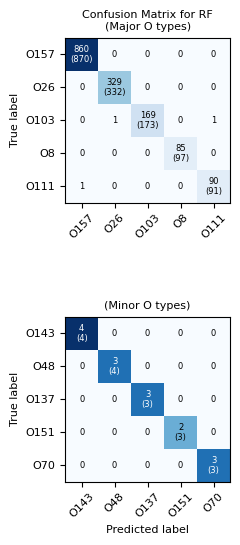

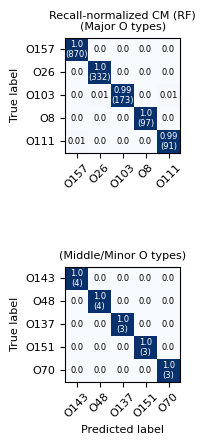

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# =========================
# 0) Train/Test 샘플명 로드
# =========================
with open("global_test_set_name.txt", "r") as infile:
    global_test_set_name = {line.strip("\n") for line in infile}

with open("global_train_set_name.txt", "r") as infile:
    global_train_set_name = {line.strip("\n") for line in infile}

# =========================
# 1) DataMat_allgene에서 train/test split (acc 기준)
# =========================
# DataMat_allgene: columns = ["acc", "answer", feat...]
df = DataMat_allgene.copy()

train_df = df[df["acc"].isin(global_train_set_name)].copy()
test_df  = df[df["acc"].isin(global_test_set_name)].copy()

print("train:", train_df.shape, "test:", test_df.shape)

# feature matrix / labels
feat_cols = [c for c in df.columns if c not in ["acc", "answer"]]
X_train = train_df[feat_cols].to_numpy()
y_train = train_df["answer"].astype(str).to_numpy()

X_test = test_df[feat_cols].to_numpy()
y_test = test_df["answer"].astype(str).to_numpy()

# =========================
# 2) RF 학습 + 예측
# =========================
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=33,
    n_jobs=40,
    class_weight="balanced_subsample",  # 불균형 대응(원치 않으면 None)
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

# =========================
# 3) confusion matrix 대상 라벨(major/middle) 만들기
#    - 빈도 기준은 train set에서 계산 추천
# =========================
train_counts = pd.Series(y_train).value_counts()

major_O_list  = list(train_counts.index[:5])
#middle_O_list = list(train_counts.index[120:125])  # 네 로직 유지
middle_O_list = ["O143", "O48", "O137", "O151", "O70"]

# =========================
# 4) confusion matrix 계산
# =========================
major_cm  = confusion_matrix(y_test, y_pred, labels=major_O_list)
middle_cm = confusion_matrix(y_test, y_pred, labels=middle_O_list)

# (선택) row-normalized (Recall 기준)
major_row_sum  = major_cm.sum(axis=1, keepdims=True)
middle_row_sum = middle_cm.sum(axis=1, keepdims=True)

major_cm_rt  = np.divide(major_cm,  major_row_sum,  out=np.zeros_like(major_cm, dtype=float),  where=major_row_sum!=0)
middle_cm_rt = np.divide(middle_cm, middle_row_sum, out=np.zeros_like(middle_cm, dtype=float), where=middle_row_sum!=0)

# =========================
# 5) 저장 (csv)
# =========================
out_prefix = "RF_globalSplit"

pd.DataFrame(major_cm, index=major_O_list, columns=major_O_list).to_csv(f"{out_prefix}.major_cm.counts.csv")
pd.DataFrame(middle_cm, index=middle_O_list, columns=middle_O_list).to_csv(f"{out_prefix}.middle_cm.counts.csv")

pd.DataFrame(major_cm_rt, index=major_O_list, columns=major_O_list).to_csv(f"{out_prefix}.major_cm.recall.csv")
pd.DataFrame(middle_cm_rt, index=middle_O_list, columns=middle_O_list).to_csv(f"{out_prefix}.middle_cm.recall.csv")

# =========================
# 6) plot 함수 (네 스타일 유지 + 저장)
# =========================
def plot_confusion_matrix(ax, cm, labels, row_sum, title, ylabel, xlabel):
    ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title, fontsize=8)

    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(labels, rotation=45, fontsize=8)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(labels, fontsize=8)

    thresh = cm.max() / 2. if cm.size else 0
    for i, j in np.ndindex(cm.shape):
        # diag에 true count(row_sum) 같이 표기
        if i == j:
            txt = f"{cm[i,j]}\n({row_sum[i]})"
        else:
            txt = f"{cm[i,j]}"
        ax.text(j, i, txt, ha="center", va="center", fontsize=6,
                color="white" if cm[i, j] > thresh else "black")

    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xlabel(xlabel, fontsize=8)

# row_sum(= true label별 test 개수) : 시각화에 쓰는 값은 test 기준이 맞음
major_test_counts  = np.array([(y_test == lab).sum() for lab in major_O_list])
middle_test_counts = np.array([(y_test == lab).sum() for lab in middle_O_list])

fig, ax = plt.subplots(2, 1, figsize=(2.5, 6))
plot_confusion_matrix(ax[0], major_cm, major_O_list, major_test_counts,
                      "Confusion Matrix for RF\n(Major O types)", "True label", "")
plot_confusion_matrix(ax[1], middle_cm, middle_O_list, middle_test_counts,
                      "(Minor O types)", "True label", "Predicted label")

plt.tight_layout()
plt.savefig(f"{out_prefix}.major_middle_cm.counts.png", dpi=300, bbox_inches="tight")
plt.show()

# (선택) recall 버전도 그림 저장하고 싶으면 아래처럼:
fig, ax = plt.subplots(2, 1, figsize=(2, 5))
plot_confusion_matrix(ax[0], np.round(major_cm_rt, 2), major_O_list, major_test_counts,
                      "Recall-normalized CM (RF)\n(Major O types)", "True label", "")
plot_confusion_matrix(ax[1], np.round(middle_cm_rt, 2), middle_O_list, middle_test_counts,
                      "(Middle/Minor O types)", "True label", "Predicted label")
plt.tight_layout()
plt.savefig(f"{out_prefix}.major_middle_cm.recall.png", dpi=300, bbox_inches="tight")
plt.show()


train: (7885, 2562) test: (3375, 2562)
n_features: 2560
Elapsed time for 10 RF runs: 175.74 sec
                  feature  importance_mean  importance_std      label
0       MBGD66_CDHIT0_v89         0.002093        0.000123   garR_v89
1       MBGD66_CDHIT0_v76         0.001913        0.000161   garR_v76
2      MBGD66_CDHIT0_v204         0.001794        0.000114  garR_v204
3   MBGD35854_CDHIT1_v245         0.001779        0.000161  wcaM_v245
4       MBGD66_CDHIT0_v40         0.001775        0.000132   garR_v40
5       MBGD66_CDHIT0_v32         0.001692        0.000099   garR_v32
6     MBGD117_CDHIT3_v250         0.001667        0.000132  glmM_v250
7     MBGD7478_CDHIT4_v78         0.001592        0.000135   wzzE_v78
8      MBGD66_CDHIT0_v100         0.001548        0.000115  garR_v100
9      MBGD66_CDHIT0_v167         0.001535        0.000086  garR_v167
10     MBGD66_CDHIT0_v158         0.001516        0.000072  garR_v158
11   MBGD35854_CDHIT1_v79         0.001507        0.000149   wca

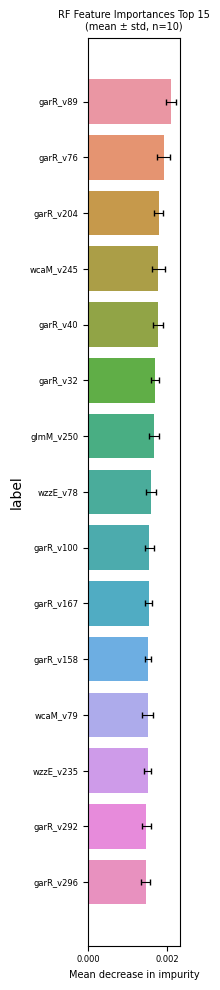

In [26]:
# =========================
# RF Feature Importance (10회 반복) + mean 기준 TopN 정렬 + std 에러바 plot
# - 입력: DataMat_allgene (columns: acc, answer, features...)
# - 입력: global_train_set_name, global_test_set_name (set of sample names)
# - 입력(선택): ClusterMeta (dict; key=MBGD cluster id, value={"gene":...})
# =========================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier


# -------------------------------------------------
# 0) (선택) global_train/test_set_name 로드가 아직이면
# -------------------------------------------------
# with open("global_test_set_name.txt", "r") as infile:
#     global_test_set_name = {line.strip("\n") for line in infile}
# with open("global_train_set_name.txt", "r") as infile:
#     global_train_set_name = {line.strip("\n") for line in infile}


# -------------------------------------------------
# 1) DataMat_allgene -> train/test split
# -------------------------------------------------
df = DataMat_allgene.copy()

train_df = df[df["acc"].isin(global_train_set_name)].copy()
test_df  = df[df["acc"].isin(global_test_set_name)].copy()

feat_cols = [c for c in df.columns if c not in ["acc", "answer"]]

X_train = train_df[feat_cols].to_numpy()
y_train = train_df["answer"].astype(str).to_numpy()

# (중요) 혹시라도 NaN 남아있으면 안전하게 한 번 더
# train_df[feat_cols] = train_df[feat_cols].fillna(0)
# test_df[feat_cols]  = test_df[feat_cols].fillna(0)

feature_names = pd.Index(feat_cols)

print("train:", train_df.shape, "test:", test_df.shape)
print("n_features:", len(feat_cols))


# -------------------------------------------------
# 2) feature -> gene_v 라벨 변환 (ClusterMeta 있으면 gene 붙임)
# -------------------------------------------------
def feat_to_gene_label(feat: str, ClusterMeta=None) -> str:
    """
    feat 예: MBGD66_CDHIT0_v13
    -> gene_v13 (ClusterMeta가 있으면 gene 이름 사용)
    """
    cluster_part = feat.split("_")[0]          # "MBGD66"
    cluster_id = cluster_part.replace("MBGD", "")  # "66"
    v_part = feat.split("_")[-1]              # "v13"

    gene = f"MBGD{cluster_id}"  # fallback
    if ClusterMeta is not None:
        # ClusterMeta 키가 int 또는 str 둘 다 가능하게 처리
        if cluster_id in ClusterMeta and isinstance(ClusterMeta[cluster_id], dict) and "gene" in ClusterMeta[cluster_id]:
            gene = ClusterMeta[cluster_id]["gene"]
        else:
            try:
                cid = int(cluster_id)
                if cid in ClusterMeta and isinstance(ClusterMeta[cid], dict) and "gene" in ClusterMeta[cid]:
                    gene = ClusterMeta[cid]["gene"]
            except:
                pass

    return f"{gene}_{v_part}"


# -------------------------------------------------
# 3) RF 10회 반복 학습 + feature_importances_ 수집
# -------------------------------------------------
n_repeat = 10
base_seed = 33

rf_params = dict(
    n_estimators=500,
    n_jobs=50,
    class_weight="balanced_subsample",  # 원치 않으면 None
)

all_importances = np.zeros((n_repeat, len(feat_cols)), dtype=float)

t0 = time.time()
for i in range(n_repeat):
    rf = RandomForestClassifier(random_state=base_seed + i, **rf_params)
    rf.fit(X_train, y_train)
    all_importances[i, :] = rf.feature_importances_

elapsed = time.time() - t0
print(f"Elapsed time for {n_repeat} RF runs: {elapsed:.2f} sec")


# -------------------------------------------------
# 4) mean / std 계산 + mean 기준 정렬
# -------------------------------------------------
imp_mean = all_importances.mean(axis=0)
imp_std  = all_importances.std(axis=0)

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": imp_mean,
    "importance_std": imp_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

topN = 15
top_df = imp_df.head(topN).copy()
top_df["label"] = [feat_to_gene_label(f, ClusterMeta=globals().get("ClusterMeta", None)) for f in top_df["feature"]]

print(top_df)


# -------------------------------------------------
# 5) 저장 (전체 / TopN)
# -------------------------------------------------
out_prefix = "RF_globalSplit_importance_10runs"
imp_df.to_csv(f"{out_prefix}.all_features.mean_std.csv", index=False)
top_df.to_csv(f"{out_prefix}.top{topN}.mean_std.csv", index=False)


# -------------------------------------------------
# 6) Bar plot + std (errorbar)
#    - seaborn barplot + matplotlib errorbar 조합
# -------------------------------------------------
plt.figure(figsize=(2, 10))
plt.title(f"RF Feature Importances Top {topN}\n(mean ± std, n={n_repeat})", fontsize=7)

# seaborn은 순서를 유지하려면 y를 category로 잡는 게 편함
# (이미 top_df가 mean 내림차순)
ax = sns.barplot(
    data=top_df,
    x="importance_mean",
    y="label",
    orient="h"
)

# errorbar: bar 중앙 y 좌표는 0..topN-1로 맞춰주면 됨
y_pos = np.arange(len(top_df))
plt.errorbar(
    top_df["importance_mean"].to_numpy(),
    y_pos,
    xerr=top_df["importance_std"].to_numpy(),
    fmt="none",
    ecolor="black",
    elinewidth=0.8,
    capsize=2
)

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.xlabel("Mean decrease in impurity", fontsize=7)
plt.tight_layout()
plt.savefig(f"{out_prefix}.top{topN}.bar_mean_std.png", dpi=300, bbox_inches="tight")
plt.show()


In [28]:
import numpy as np
import pandas as pd
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import spearmanr, pearsonr

# =========================
# 0) 공통 설정
# =========================
n_repeat = 10
base_seed = 33

rf_params = dict(
    n_estimators=500,
    n_jobs=50,
    #class_weight="balanced_subsample",
)

# =========================
# 1) padding 값별 DataMat 생성 함수
# =========================
def build_DataMat_with_padding(DataMat_list, pad_value):
    """
    pad_value: 0, 1, -1
    """
    DataMat = DataMat_list[1].copy()

    for i in range(2, len(DataMat_list)):
        DataMat = DataMat.merge(
            DataMat_list[i].drop(columns=["answer"], errors="ignore"),
            on="acc",
            how="left"
        )

    feat_cols = [c for c in DataMat.columns if c not in ["acc", "answer"]]
    DataMat[feat_cols] = DataMat[feat_cols].fillna(pad_value)

    return DataMat, feat_cols


# =========================
# 2) RF 반복 학습 → accuracy + importance
# =========================
def run_rf_repeat(DataMat, feat_cols, pad_label):
    train_df = DataMat[DataMat["acc"].isin(global_train_set_name)]
    test_df  = DataMat[DataMat["acc"].isin(global_test_set_name)]

    X_train = train_df[feat_cols].to_numpy()
    y_train = train_df["answer"].astype(str).to_numpy()

    X_test = test_df[feat_cols].to_numpy()
    y_test = test_df["answer"].astype(str).to_numpy()

    acc_list = []
    imp_list = []

    for i in range(n_repeat):
        rf = RandomForestClassifier(
            random_state=base_seed + i,
            **rf_params
        )
        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_test)
        acc_list.append(accuracy_score(y_test, y_pred))
        imp_list.append(rf.feature_importances_)

    acc_list = np.array(acc_list)
    imp_arr = np.vstack(imp_list)

    return {
        "pad": pad_label,
        "acc_mean": acc_list.mean(),
        "acc_std": acc_list.std(),
        "importance_mean": imp_arr.mean(axis=0),
    }


# =========================
# 3) padding별 실험 수행
# =========================
results = {}

for pad in [0, 1, -1]:
    print(f"\n=== Padding = {pad} ===")
    DataMat_pad, feat_cols = build_DataMat_with_padding(DataMat_list, pad)
    results[pad] = run_rf_repeat(DataMat_pad, feat_cols, pad)

# =========================
# 4) Accuracy 비교 표
# =========================
acc_df = pd.DataFrame([
    {
        "padding": pad,
        "acc_mean": results[pad]["acc_mean"],
        "acc_std": results[pad]["acc_std"],
    }
    for pad in results
])

print("\n=== Test accuracy comparison ===")
print(acc_df)

# =========================
# 5) Feature importance 상관 비교
# =========================
def compare_importance(pad_a, pad_b):
    imp_a = results[pad_a]["importance_mean"]
    imp_b = results[pad_b]["importance_mean"]

    sp = spearmanr(imp_a, imp_b).correlation
    pr = pearsonr(imp_a, imp_b)[0]
    return sp, pr


print("\n=== Feature importance correlation ===")
for a, b in [(0, 1), (0, -1), (1, -1)]:
    sp, pr = compare_importance(a, b)
    print(f"padding {a} vs {b}: Spearman={sp:.4f}, Pearson={pr:.4f}")



=== Padding = 0 ===

=== Padding = 1 ===

=== Padding = -1 ===

=== Test accuracy comparison ===
   padding  acc_mean   acc_std
0        0  0.931496  0.000619
1        1  0.930933  0.000599
2       -1  0.931319  0.000660

=== Feature importance correlation ===
padding 0 vs 1: Spearman=0.8579, Pearson=0.8540
padding 0 vs -1: Spearman=0.8577, Pearson=0.8999
padding 1 vs -1: Spearman=0.7217, Pearson=0.7476


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, auc,
    roc_auc_score, average_precision_score
)
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb


# =========================
# 0) 설정
# =========================
DataMat = DataMat_allgene        # <- 네 DF
USE_BALANCE = False              # <- 가중치 on/off
min_count = 3                   # <- stratify 가능한 최소 샘플수(보수적으로 3 권장)

test_ratio = 0.3                # 7:3
split_seed = 33                 # split 고정 seed
nRepeat = 10
base_seed = 33                  # 반복 학습 seed 시작값
curve_seed = 33                 # ROC/PR curve를 저장할 대표 seed (보통 base_seed와 동일)

out_txt = "revision_ML_performance_260127_pad1.txt"
out_dir = "roc_pr_curves_260127_strat70_30_pad1"
os.makedirs(out_dir, exist_ok=True)


# =========================
# 1) 희귀 클래스 제거 (stratify 예외처리)
# =========================
counts = DataMat["answer"].value_counts()
valid_classes = counts[counts >= min_count].index
removed_classes = counts[counts < min_count]

DataMat_f = DataMat[DataMat["answer"].isin(valid_classes)].copy()

print(f"[Filter] min_count={min_count}")
print(f"[Filter] kept classes: {len(valid_classes)} | removed classes: {len(removed_classes)}")
if len(removed_classes) > 0:
    print("[Filter] removed (top 20):")
    print(removed_classes.head(20))

if DataMat_f["answer"].nunique() < 2:
    raise ValueError("After filtering, <2 classes remain. Lower min_count or add data.")


# =========================
# 2) Stratified train/test split (7:3) - 한번만 고정
# =========================
drop_cols = ["answer", "acc"]
if "entero_acc" in DataMat_f.columns:
    drop_cols.append("entero_acc")

X = DataMat_f.drop(columns=drop_cols).fillna(0)
y = DataMat_f["answer"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_ratio,
    stratify=y,
    random_state=split_seed,
)

# label encoding (공통)
le = LabelEncoder()
y_train_int = le.fit_transform(y_train)
y_test_int = le.transform(y_test)
K = len(le.classes_)

# micro-average curve용 (N,K) one-hot
Y_test_bin = label_binarize(y_test_int, classes=np.arange(K))

present_classes = np.array(sorted(set(np.unique(y_test_int))), dtype=int)
if present_classes.size < 2:
    raise ValueError("Test split has only one class. Increase min_count or change split_seed.")


# =========================
# 3) 안전한 weighted OvR AUC/AP (확률 필요 없음: decision_function도 OK)
# =========================
def safe_weighted_ovr_roc_auc_binary(y_test_int, S, present_classes):
    aucs, weights = [], []
    for c in present_classes:
        y_true = (y_test_int == c).astype(int)
        if len(np.unique(y_true)) < 2:
            continue
        aucs.append(roc_auc_score(y_true, S[:, c]))
        weights.append(y_true.sum())
    if len(aucs) == 0:
        return np.nan
    weights = np.array(weights, dtype=float)
    return float(np.sum(np.array(aucs) * weights) / np.sum(weights))

def safe_weighted_ovr_ap_binary(y_test_int, S, present_classes):
    aps, weights = [], []
    for c in present_classes:
        y_true = (y_test_int == c).astype(int)
        if len(np.unique(y_true)) < 2:
            continue
        aps.append(average_precision_score(y_true, S[:, c]))
        weights.append(y_true.sum())
    if len(aps) == 0:
        return np.nan
    weights = np.array(weights, dtype=float)
    return float(np.sum(np.array(aps) * weights) / np.sum(weights))


# =========================
# 4) 모델 생성 / 학습 / score
# =========================
def build_estimator(model_name: str, seed: int, use_balance: bool):
    if model_name == "RF":
        return RandomForestClassifier(
            n_estimators=100,
            random_state=seed,
            n_jobs=40,
            criterion="entropy",
            max_depth=10,
            class_weight=("balanced" if use_balance else None),
        )
    if model_name == "GNB":
        return GaussianNB()
    if model_name == "SVC":
        return svm.SVC(
            kernel="linear",
            class_weight=("balanced" if use_balance else None),
        )
    if model_name == "MLP":
        return MLPClassifier(solver="adam", random_state=seed, hidden_layer_sizes=[500])
    if model_name == "KNN":
        return KNeighborsClassifier(n_jobs=40)
    if model_name == "XGB":
        return xgb.XGBClassifier(
            n_jobs=40,
            max_depth=10,
            eta=0.1,
            random_state=seed,
            seed=seed,
        )
    raise ValueError(model_name)

def fit_with_optional_sample_weight(model_name, clf, X_train, y_train_int, use_balance):
    # RF/SVC는 class_weight로 처리됨.
    # 나머지는 가능하면 sample_weight로 balanced 효과.
    sample_weight = None
    if use_balance and (model_name not in ["RF", "SVC", "KNN"]):
        sample_weight = compute_sample_weight(class_weight="balanced", y=y_train_int)

    try:
        if sample_weight is not None:
            clf.fit(X_train, y_train_int, sample_weight=sample_weight)
        else:
            clf.fit(X_train, y_train_int)
    except TypeError:
        clf.fit(X_train, y_train_int)
    return clf

def get_score_matrix(clf, X):
    if hasattr(clf, "predict_proba"):
        S = clf.predict_proba(X)
    elif hasattr(clf, "decision_function"):
        S = clf.decision_function(X)
        if S.ndim == 1:  # binary
            S = np.vstack([-S, S]).T
    else:
        raise ValueError("Model has neither predict_proba nor decision_function.")
    return S

def fix_score_shape_to_K(clf, S, K):
    if S.shape[1] == K:
        return S
    S_fixed = np.zeros((S.shape[0], K), dtype=float)
    if hasattr(clf, "classes_"):
        for j, c in enumerate(clf.classes_):
            S_fixed[:, int(c)] = S[:, j]
    return S_fixed


# =========================
# 5) 10번 반복 metric 평가 (split은 고정)
# =========================
models = ["RF", "GNB", "SVC", "MLP", "KNN", "XGB"]

metrics = defaultdict(lambda: {
    "acc": [], "prc": [], "recall": [], "f1": [],
    "roc_micro_auc": [], "roc_weighted_ovr": [],
    "pr_micro_auc": [], "pr_weighted_ap": []
})

for r in range(nRepeat):
    seed_model = base_seed + r

    for model_name in models:
        clf = build_estimator(model_name, seed_model, USE_BALANCE)
        clf = fit_with_optional_sample_weight(model_name, clf, X_train, y_train_int, USE_BALANCE)

        # 예측 라벨
        y_pred_int = clf.predict(X_test)

        # classification metrics (weighted)
        metrics[model_name]["acc"].append(accuracy_score(y_test_int, y_pred_int))
        metrics[model_name]["prc"].append(precision_score(y_test_int, y_pred_int, average="weighted", zero_division=0))
        metrics[model_name]["recall"].append(recall_score(y_test_int, y_pred_int, average="weighted", zero_division=0))
        metrics[model_name]["f1"].append(f1_score(y_test_int, y_pred_int, average="weighted"))

        # score matrix -> AUC
        S = get_score_matrix(clf, X_test)
        S = fix_score_shape_to_K(clf, S, K)

        # ROC micro AUC (curve 기반)
        fpr, tpr, _ = roc_curve(Y_test_bin.ravel(), S.ravel())
        metrics[model_name]["roc_micro_auc"].append(auc(fpr, tpr))

        # ROC weighted OvR(binary aggregation; proba 필요 없음)
        metrics[model_name]["roc_weighted_ovr"].append(
            safe_weighted_ovr_roc_auc_binary(y_test_int, S, present_classes)
        )

        # PR micro AUC (curve 기반)
        prec, rec, _ = precision_recall_curve(Y_test_bin.ravel(), S.ravel())
        metrics[model_name]["pr_micro_auc"].append(auc(rec, prec))

        # PR weighted AP(binary aggregation)
        metrics[model_name]["pr_weighted_ap"].append(
            safe_weighted_ovr_ap_binary(y_test_int, S, present_classes)
        )


# =========================
# 6) ROC/PR curve 그림은 대표 seed 1개로 저장
# =========================
curve_paths = {}
for model_name in models:
    clf = build_estimator(model_name, curve_seed, USE_BALANCE)
    clf = fit_with_optional_sample_weight(model_name, clf, X_train, y_train_int, USE_BALANCE)

    S = get_score_matrix(clf, X_test)
    S = fix_score_shape_to_K(clf, S, K)

    # ROC curve + AUC
    fpr, tpr, _ = roc_curve(Y_test_bin.ravel(), S.ravel())
    roc_micro_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} ROC (micro AUC={roc_micro_auc:.4f})")
    plt.tight_layout()
    roc_path = os.path.join(out_dir, f"ROC_{model_name}_curveSeed{curve_seed}_strat70_30.png")
    plt.savefig(roc_path, dpi=200)
    plt.close()

    # PR curve + AUC
    prec, rec, _ = precision_recall_curve(Y_test_bin.ravel(), S.ravel())
    pr_micro_auc = auc(rec, prec)

    plt.figure()
    plt.plot(rec, prec)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} PR (micro AUC={pr_micro_auc:.4f})")
    plt.tight_layout()
    pr_path = os.path.join(out_dir, f"PR_{model_name}_curveSeed{curve_seed}_strat70_30.png")
    plt.savefig(pr_path, dpi=200)
    plt.close()

    curve_paths[model_name] = (roc_path, pr_path)


# =========================
# 7) mean/std 로깅 + 파일 저장
# =========================
def mean_std(arr):
    arr = np.array(arr, dtype=float)
    return arr.mean(), arr.std(ddof=1)

lines = []
lines.append("===== Stratified 70/30 (fixed split) + 10x training repeats =====")
lines.append(f"min_count={min_count} | removed_classes={len(removed_classes)}")
lines.append(f"test_ratio={test_ratio} | split_seed={split_seed}")
lines.append(f"nRepeat={nRepeat} | base_seed={base_seed} | curve_seed={curve_seed}")
lines.append(f"USE_BALANCE={USE_BALANCE}")
lines.append(f"Train n={len(y_train_int)} | Test n={len(y_test_int)} | K={K}")
lines.append(f"Curves saved to: {out_dir}")
lines.append("")
lines.append("model\tacc(mean±std)\tprc(mean±std)\trecall(mean±std)\tf1(mean±std)\tROC_micro(mean±std)\tROC_weightedOvR(mean±std)\tPR_micro(mean±std)\tPR_weightedAP(mean±std)")
lines.append("")

for model_name in models:
    a_m,a_s = mean_std(metrics[model_name]["acc"])
    p_m,p_s = mean_std(metrics[model_name]["prc"])
    r_m,r_s = mean_std(metrics[model_name]["recall"])
    f_m,f_s = mean_std(metrics[model_name]["f1"])
    rm_m,rm_s = mean_std(metrics[model_name]["roc_micro_auc"])
    rw_m,rw_s = mean_std(metrics[model_name]["roc_weighted_ovr"])
    pm_m,pm_s = mean_std(metrics[model_name]["pr_micro_auc"])
    pw_m,pw_s = mean_std(metrics[model_name]["pr_weighted_ap"])

    lines.append(
        f"{model_name}\t"
        f"{a_m:.6f}±{a_s:.6f}\t"
        f"{p_m:.6f}±{p_s:.6f}\t"
        f"{r_m:.6f}±{r_s:.6f}\t"
        f"{f_m:.6f}±{f_s:.6f}\t"
        f"{rm_m:.6f}±{rm_s:.6f}\t"
        f"{rw_m:.6f}±{rw_s:.6f}\t"
        f"{pm_m:.6f}±{pm_s:.6f}\t"
        f"{pw_m:.6f}±{pw_s:.6f}"
    )

lines.append("")
lines.append("===== Curve PNG paths (generated with curve_seed) =====")
for model_name in models:
    roc_path, pr_path = curve_paths[model_name]
    lines.append(f"{model_name}\tROC={roc_path}\tPR={pr_path}")

with open(out_txt, "a") as f:
    f.write("\n" + "\n".join(lines) + "\n")

print("\n".join(lines))


[Filter] min_count=3
[Filter] kept classes: 174 | removed classes: 15
[Filter] removed (top 20):
O42     2
O12     2
O28     2
O265    1
O406    1
O421    1
O401    1
O30     1
O410    1
O155    1
O188    1
O56     1
O408    1
O97     1
O50     1
Name: answer, dtype: int64


In [15]:
ectyper_stat = pd.read_csv("Eco_over1Mb_251218/apple/ECTyper/output.tsv", sep="\t")
ectyper_stat = ectyper_stat[~ectyper_stat["Warnings"].str.contains("Non fasta")]
ectyper_stat["Name"] = list(ectyper_stat.Name.str.split(".").str[0])
ectyper_merged = pd.merge(left=ectyper_stat, right=meta, how="left", left_on="Name", right_on="acc")
ectyper_merged

,Name,Species,O-type,H-type,Serotype,QC,Evidence,GeneScores,AlleleKeys,GeneIdentities(%),GeneCoverages(%),GeneContigNames,GeneRanges,GeneLengths,Database,Warnings,acc,O,H
0,ESC_AD0116AA_AS,-,O69,H11,O69:H11,-,Based on 3 allele(s),wzx:1;wzy:0.999;fliC:1;,O69-1-wzx-origin;O69-2-wzy-origin;H11-4-fliC;,100;99.91;100;,100;100;100;,ESC_AD0116AA_AS_NODE_11_length_135921_cov_44.1...,103992-105506;107554-108669;142157-143615;,1515;1116;1459;,v1.0 (11-03-2020),-,ESC_AD0116AA_AS,O69,H11
1,ESC_AD0138AA_AS,-,O145,-,O145:-,-,Based on 2 allele(s),wzx:1;wzy:1;,O145-3-wzx-origin;O145-21-wzy;,100;100;,100;100;,ESC_AD0138AA_AS_NODE_12_length_145237_cov_15.5...,109196-110434;110442-111592;,1239;1151;,v1.0 (11-03-2020),-,ESC_AD0138AA_AS,O145,H28
2,ESC_AD0140AA_AS,-,O103,H2,O103:H2,-,Based on 3 allele(s),wzx:1;wzy:1;fliC:1;,O103-7-wzx-origin;O103-38-wzy;H2-2-fliC-origin;,100;100;100;,100;100;100;,ESC_AD0140AA_AS_NODE_2_length_352537_cov_15.23...,316732-317997;319884-321028;158300-159793;,1266;1145;1494;,v1.0 (11-03-2020),-,ESC_AD0140AA_AS,O103,H2
3,ESC_AD0142AA_AS,-,O157,H7,O157:H7,-,Based on 3 allele(s),wzx:1;wzy:1;fliC:1;,O157-1-wzx-origin;O157-118-wzy;H7-1-fliC-origin;,100;100;100;,100;100;100;,ESC_AD0142AA_AS_NODE_17_length_99356_cov_16.56...,67575-68966;65707-66873;11424-13181;,1392;1167;1758;,v1.0 (11-03-2020),-,ESC_AD0142AA_AS,O157,H7
4,ESC_AD0148AA_AS,-,O145,-,O145:-,-,Based on 2 allele(s),wzx:1;wzy:1;,O145-3-wzx-origin;O145-21-wzy;,100;100;,100;100;,ESC_AD0148AA_AS_NODE_12_length_145237_cov_15.6...,109196-110434;110442-111592;,1239;1151;,v1.0 (11-03-2020),-,ESC_AD0148AA_AS,O145,H28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1706,ESC_ZC9915AA_AS,-,O26,H11,O26:H11,-,Based on 3 allele(s),wzx:1;wzy:1;fliC:1;,O26-3-wzx;O26-5-wzy;H11-4-fliC;,100;100;100;,100;100;100;,ESC_ZC9915AA_AS_NODE_16_length_113004_cov_49.8...,77768-79030;79096-80118;71753-73211;,1263;1023;1459;,v1.0 (11-03-2020),-,ESC_ZC9915AA_AS,O26,H11
1707,ESC_ZC9943AA_AS,-,O157,H7,O157:H7,-,Based on 3 allele(s),wzx:1;wzy:1;fliC:1;,O157-1-wzx-origin;O157-118-wzy;H7-1-fliC-origin;,100;100;100;,100;100;100;,ESC_ZC9943AA_AS_NODE_14_length_142085_cov_9.89...,110347-111738;108479-109645;11380-13137;,1392;1167;1758;,v1.0 (11-03-2020),-,ESC_ZC9943AA_AS,O157,H7
1708,ESC_ZC9960AA_AS,-,O27,H30,O27:H30,-,Based on 3 allele(s),wzx:0.997;wzy:0.999;fliC:0.98;,O27-3-wzx;O27-2-wzy-origin;H30-1-fliC-origin;,99.682;99.919;98.424;,100;100;100;,ESC_ZC9960AA_AS_NODE_16_length_116773_cov_3.09...,29013-30271;32075-33307;64316-66028;,1259;1233;1713;,v1.0 (11-03-2020),-,ESC_ZC9960AA_AS,O27,H30
1709,ESC_ZC9961AA_AS,-,O109,H21,O109:H21,-,Based on 3 allele(s),wzx:1;wzy:1;fliC:1;,O109-4-wzx;O109-7-wzy;H21-12-fliC;,100;100;100;,100;100;100;,ESC_ZC9961AA_AS_NODE_16_length_102676_cov_10.4...,65776-67140;72477-73697;46752-48227;,1365;1221;1476;,v1.0 (11-03-2020),-,ESC_ZC9961AA_AS,O109,H21


In [17]:
ec_report = pd.DataFrame(classification_report(list(ectyper_merged["O"]), list(ectyper_merged["O-type"]), output_dict=True)).transpose()
ec_report

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

,precision,recall,f1-score,support
-,0.000000,0.000000,0.000000,0.000000
O1,1.000000,1.000000,1.000000,10.000000
O10,1.000000,0.800000,0.888889,5.000000
O100,1.000000,0.750000,0.857143,4.000000
O100/O154,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
O98/O8,0.000000,0.000000,0.000000,0.000000
O99,1.000000,1.000000,1.000000,12.000000
accuracy,0.957335,0.957335,0.957335,0.957335
macro avg,0.800036,0.795938,0.796463,1711.000000


In [20]:
sfTable = pd.read_csv("Eco_over1Mb_251218/apple/serotypeFinder/result.txt", sep="\t")
sfTable = sfTable[sfTable["file"].isin(list(meta["acc"]))]
compareTb = pd.merge(meta, sfTable, left_on="acc", right_on="file", how="inner")
sf_report = pd.DataFrame(classification_report(list(compareTb["O"]), list(compareTb["O_type"]), output_dict=True)).transpose()
sf_report

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

,precision,recall,f1-score,support
O1,0.909091,1.000000,0.952381,10.000000
O10,1.000000,0.600000,0.750000,5.000000
O100,1.000000,0.250000,0.400000,4.000000
O100/O154,0.000000,0.000000,0.000000,0.000000
O101,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
O9a/O9,0.000000,0.000000,0.000000,0.000000
nan,0.000000,0.000000,0.000000,0.000000
accuracy,0.950906,0.950906,0.950906,0.950906
macro avg,0.738636,0.720247,0.725265,1711.000000
